In [172]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_283027405_EA.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import dill
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     dill.load_module(session_file)
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_283027405_EA.ipynb.pkl


In [1]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

<IPython.core.display.Javascript object>

# TIC 283027405 Analysis (EA)

- new VSX entry


## TESS Data

In [17]:
tic = 283027405

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["QLP"])  # use QLP over "SPOC", "TESS-SPOC", 
# sr = sr[sr.author == "QLP"]  # for uniformity, only 1 sector (3) has no QLP data
# sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

# Note: only 1 sector of ready made lightcurve
# if needed, lightcurves can be created from sectors 37, 63, 64 (and in the future 90, 99, 100, 101)
lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 18,2019,QLP,1800,283027405,0.0,N/A
1,TESS Sector 24,2020,QLP,1800,283027405,0.0,N/A
2,TESS Sector 57,2022,QLP,200,283027405,0.0,N/A
3,TESS Sector 58,2022,QLP,200,283027405,0.0,N/A
4,TESS Sector 77,2024,QLP,200,283027405,0.0,N/A
5,TESS Sector 78,2024,QLP,200,283027405,0.0,N/A
6,TESS Sector 84,2024,QLP,200,283027405,0.0,N/A
7,TESS Sector 85,2024,QLP,200,283027405,0.0,N/A


LightCurveCollection of 8 objects:
    0: <TessLightCurve LABEL="TIC 283027405" SECTOR=18 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    1: <TessLightCurve LABEL="TIC 283027405" SECTOR=24 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    2: <TessLightCurve LABEL="TIC 283027405" SECTOR=57 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    3: <TessLightCurve LABEL="TIC 283027405" SECTOR=58 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    4: <TessLightCurve LABEL="TIC 283027405" SECTOR=77 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    5: <TessLightCurve LABEL="TIC 283027405" SECTOR=78 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    6: <TessLightCurve LABEL="TIC 283027405" SECTOR=84 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    7: <TessLightCurve LABEL="TIC 283027405" SECTOR=85 AUTHOR=QLP FLUX_ORIGIN=sap_flux>

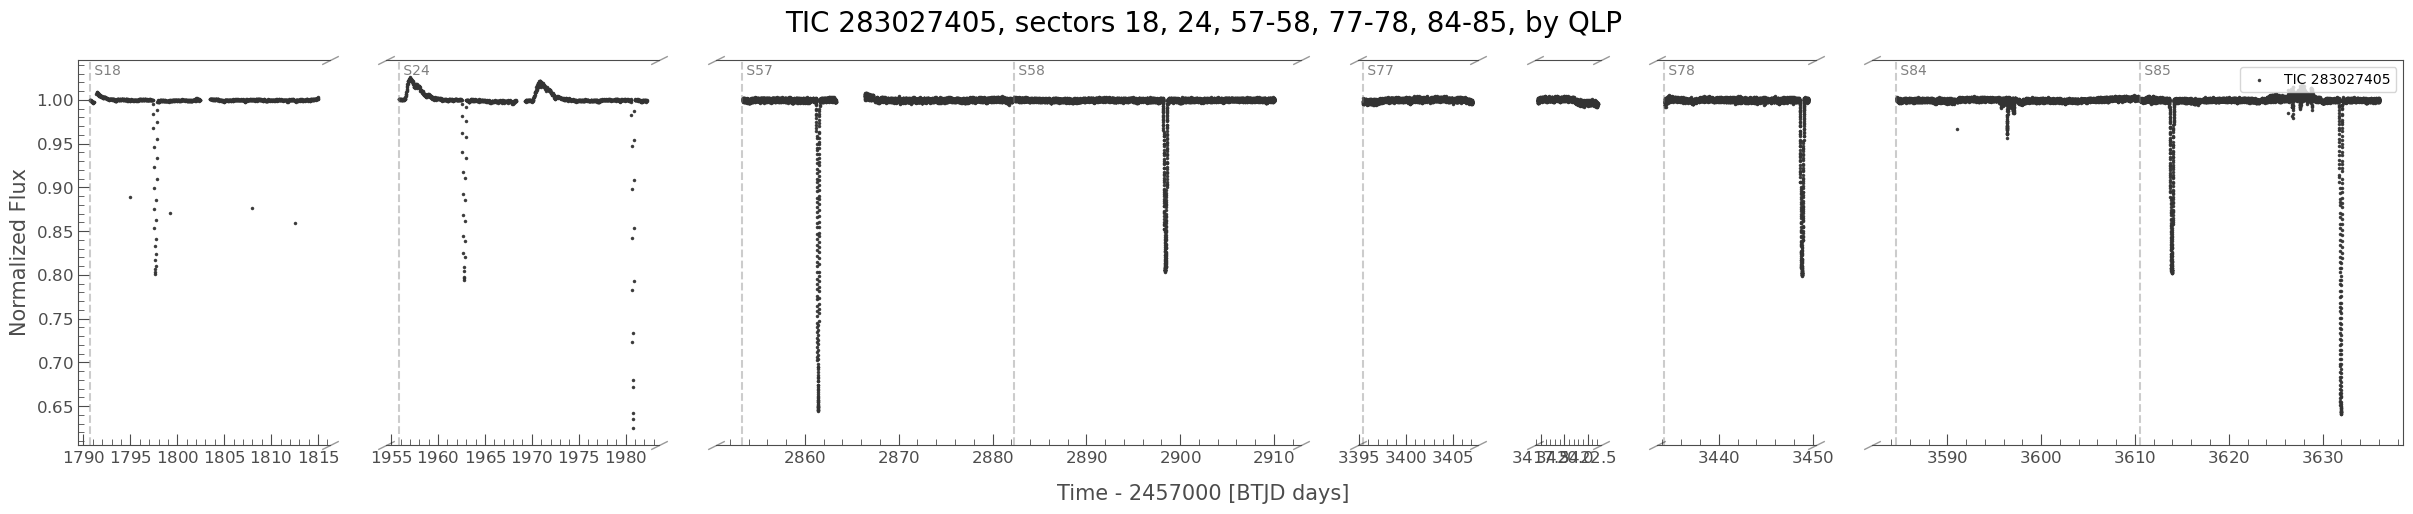

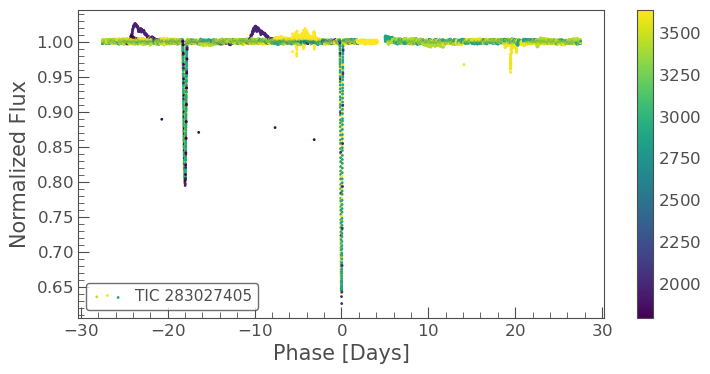

In [156]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
# [ax.set_ylim(0.9985, 1.001) for ax in axs];

_lc_f = _lc.fold(period=55.04, epoch_time=Time(2861.39, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);

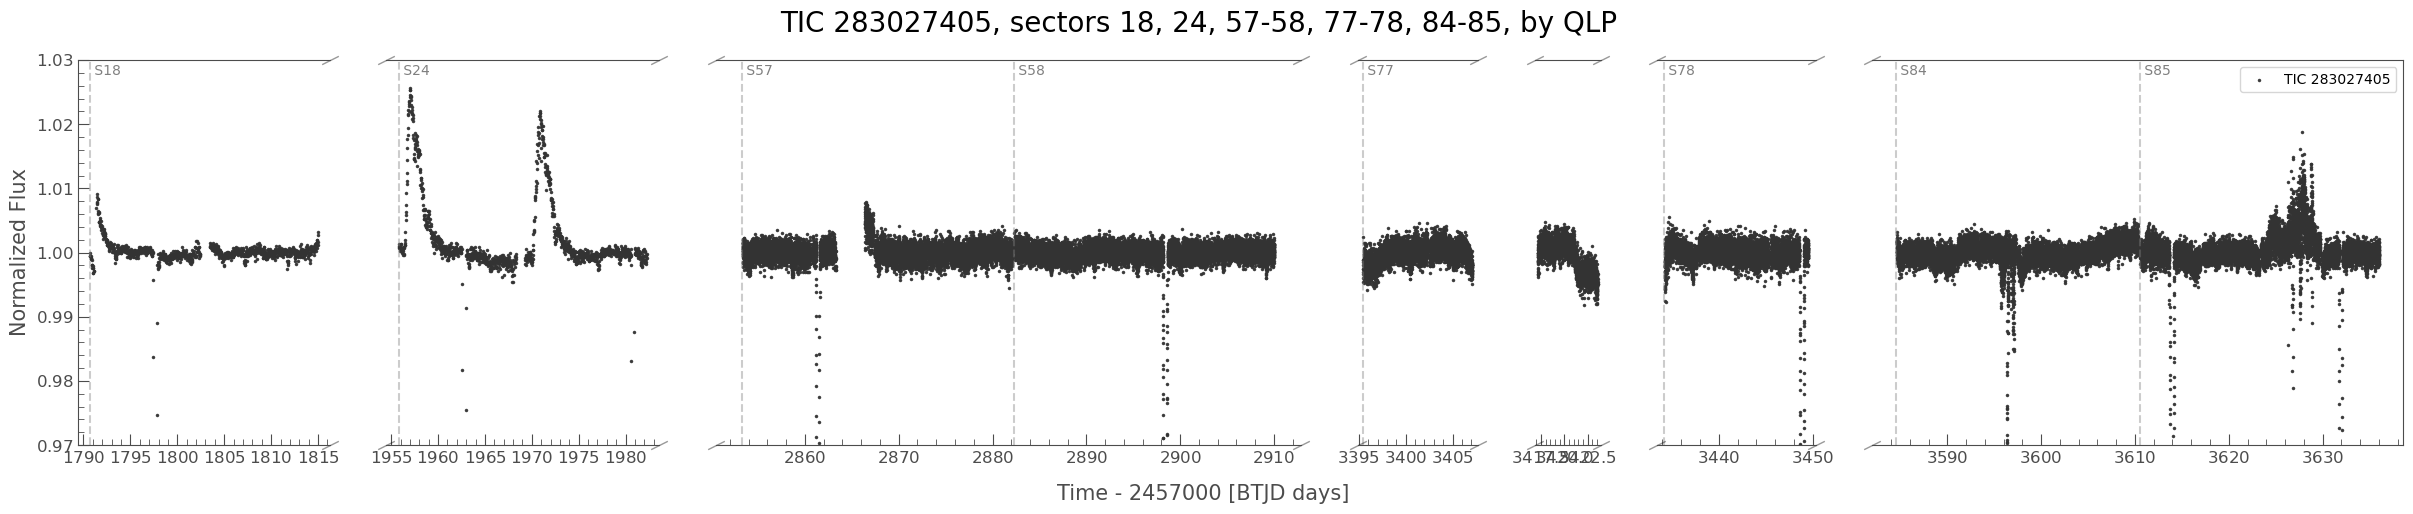

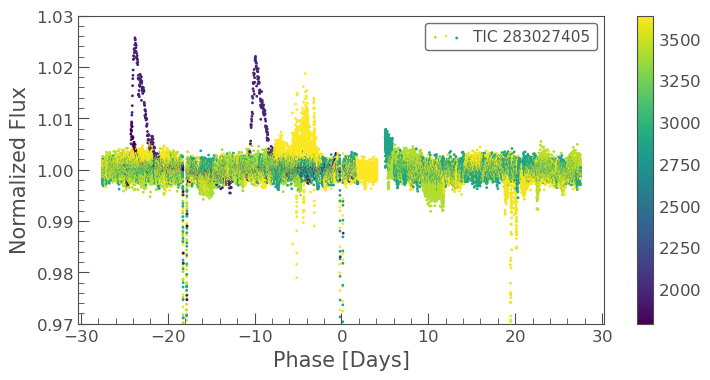

In [20]:
# truncating the eclipses to see out of eclipse variation

_ylim = (0.97, 1.03)
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author} ", fontsize=20);
[ax.set_ylim(*_ylim) for ax in axs];

ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.set_ylim(*_ylim);

### Use QLP over SPOC / TESS-SPOC data

- QLP data is used over SPOC. SPOC (PDCSAP_FLUX) data below seems to show some random-ish out-of-eclipse variation, possibly associated with issues in PDC correction
- QLP data (the above) cell seems to be cleaner. There are systematics, but are more clearly defined (and easier to mask out)

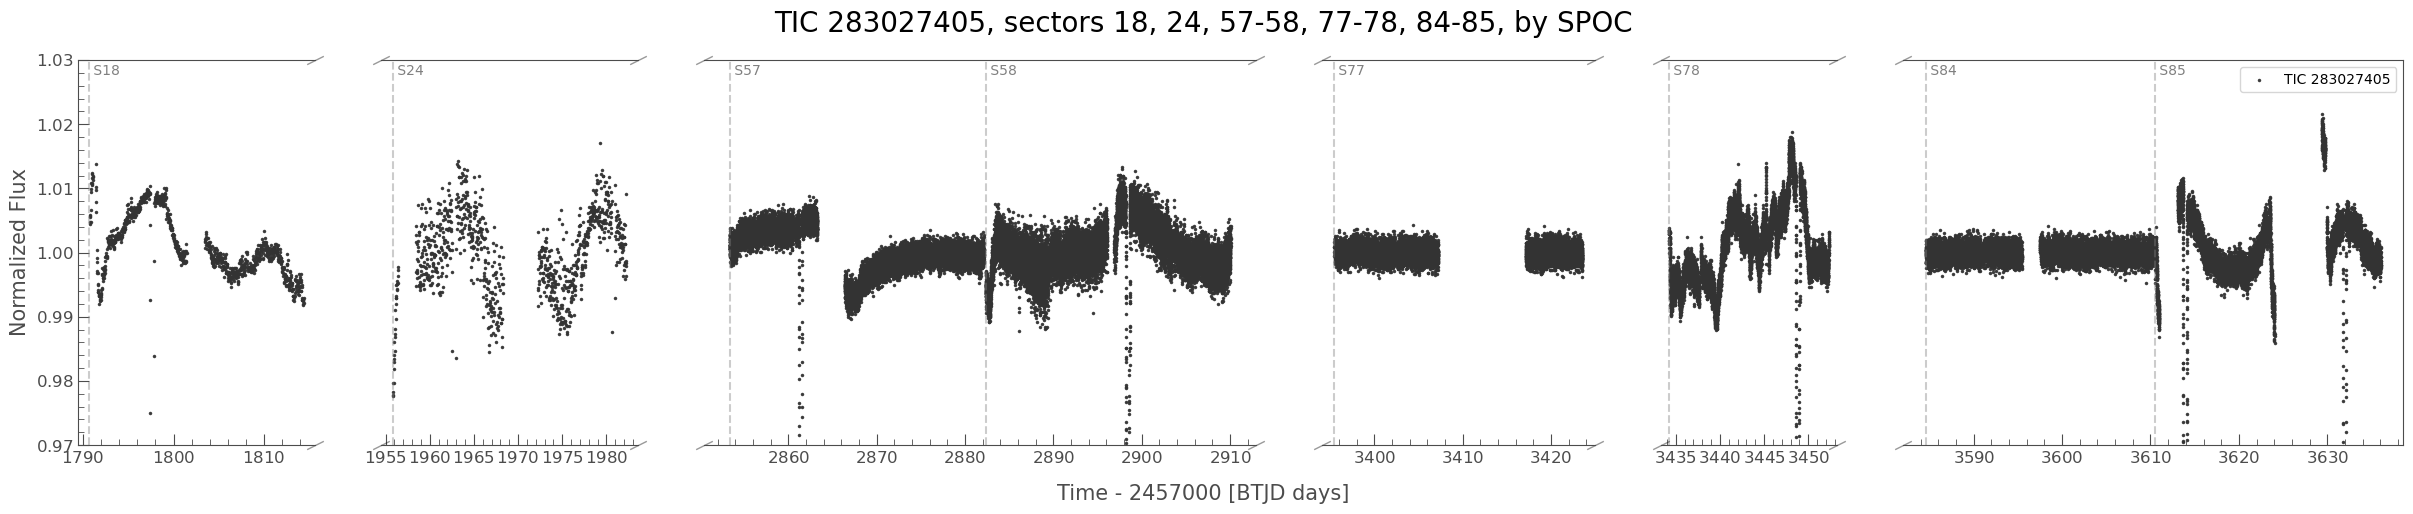
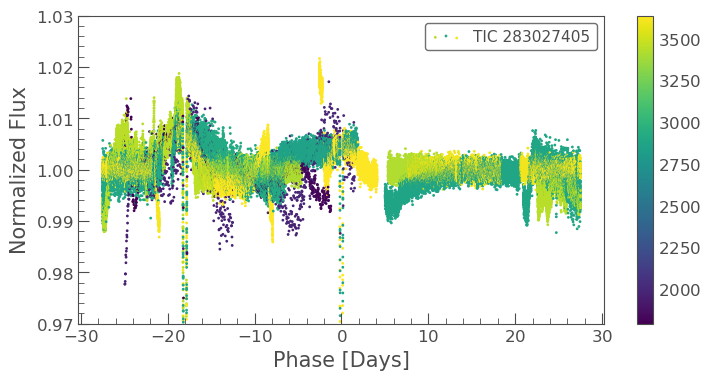



## Gaia DR3 info (coordinate, etc.)

In [15]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


C:\dev\_juypter\PH_TESS_LightCurveViewer\targets\..\lightkurve_ext.py:2296: UserWarning: gaia_dr3_mag_to_vmag(): b_minus_r value (--) is outside the applicable range for the transformation. The result is probably not reliable.
  warnings.warn(


flag,_r,_p,Source,RPmag,Gmag,BPmag,BP-RP,Vmag,Teff,RUWE,sepsi,epsi,NSS,Plx,pmRA,pmDE,VarFlag,RV,e_RV,IPDfmp,Dup,RAJ2000,DEJ2000,EpochPh,EpochRV
,arcsec,deg,,mag,mag,mag,mag,mag,K,,,mas,,mas,mas / yr,mas / yr,,km / s,km / s,,,deg,deg,,
str4,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float32,float64,str48,float64,float64,float64,str34,float64,float32,int16,uint8,float64,float64,uint8,uint8
!! ✓,0.000,0.0,<a target='vizier_gaia_dr3' href='https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6578bb1b54eda&-to=-4b&-from=-4&-this=-4&%2F%2Fsource=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fparamp&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&%2F%2Foutaddvalue=default&-order=I&-oc.form=sexa&-out.src=I%2F355%2Fgaiadr3%2CI%2F355%2Fparamp&-nav=cat%3AI%2F355%26tab%3A%7BI%2F355%2Fgaiadr3%7D%26tab%3A%7BI%2F355%2Fparamp%7D%26key%3Asource%3DI%2F355%2Fgaiadr3%26HTTPPRM%3A&-c=&-c.eq=J2000&-c.r=++2&-c.u=arcmin&-c.geom=r&-source=&-x.rs=10&-source=I%2F355%2Fgaiadr3+I%2F355%2Fparamp&-out.orig=standard&-out=RA_ICRS&-out=DE_ICRS&-out=Source&Source=429508484940144768&-out=Plx&-out=PM&-out=pmRA&-out=pmDE&-out=sepsi&-out=IPDfmp&-out=RUWE&-out=Dup&-out=Gmag&-out=BPmag&-out=RPmag&-out=BP-RP&-out=RV&-out=e_RV&-out=VarFlag&-out=NSS&-out=XPcont&-out=XPsamp&-out=RVS&-out=EpochPh&-out=EpochRV&-out=MCMCGSP&-out=MCMCMSC&-out=Teff&-out=logg&-out=%5BFe%2FH%5D&-out=Dist&-out=A0&-out=HIP&-out=PS1&-out=SDSS13&-out=SKYM2&-out=TYC2&-out=URAT1&-out=AllWISE&-out=APASS9&-out=GSC23&-out=RAVE5&-out=2MASS&-out=RAVE6&-out=RAJ2000&-out=DEJ2000&-out=Pstar&-out=PWD&-out=Pbin&-out=ABP&-out=ARP&-out=GMAG&-out=Rad&-out=SpType-ELS&-out=Rad-Flame&-out=Lum-Flame&-out=Mass-Flame&-out=Age-Flame&-out=Flags-Flame&-out=Evol&-out=z-Flame&-meta.ucd=0&-meta=0&-usenav=1&-bmark=GET'>429508484940144768,9.831,10.329,10.660,0.829,10.484,5634.6,1.413,40.8,0.172,0,4.9883,-30.016,-14.742,NOT_AVAILABLE,--,--,0,0,0.97687526446,61.60838512876,0,0
,3.208,344.7,<a target='vizier_gaia_dr3' href='https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6578bb1b54eda&-to=-4b&-from=-4&-this=-4&%2F%2Fsource=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fparamp&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&%2F%2Foutaddvalue=default&-order=I&-oc.form=sexa&-out.src=I%2F355%2Fgaiadr3%2CI%2F355%2Fparamp&-nav=cat%3AI%2F355%26tab%3A%7BI%2F355%2Fgaiadr3%7D%26tab%3A%7BI%2F355%2Fparamp%7D%26key%3Asource%3DI%2F355%2Fgaiadr3%26HTTPPRM%3A&-c=&-c.eq=J2000&-c.r=++2&-c.u=arcmin&-c.geom=r&-source=&-x.rs=10&-source=I%2F355%2Fgaiadr3+I%2F355%2Fparamp&-out.orig=standard&-out=RA_ICRS&-out=DE_ICRS&-out=Source&Source=429508484940438784&-out=Plx&-out=PM&-out=pmRA&-out=pmDE&-out=sepsi&-out=IPDfmp&-out=RUWE&-out=Dup&-out=Gmag&-out=BPmag&-out=RPmag&-out=BP-RP&-out=RV&-out=e_RV&-out=VarFlag&-out=NSS&-out=XPcont&-out=XPsamp&-out=RVS&-out=EpochPh&-out=EpochRV&-out=MCMCGSP&-out=MCMCMSC&-out=Teff&-out=logg&-out=%5BFe%2FH%5D&-out=Dist&-out=A0&-out=HIP&-out=PS1&-out=SDSS13&-out=SKYM2&-out=TYC2&-out=URAT1&-out=AllWISE&-out=APASS9&-out=GSC23&-out=RAVE5&-out=2MASS&-out=RAVE6&-out=RAJ2000&-out=DEJ2000&-out=Pstar&-out=PWD&-out=Pbin&-out=ABP&-out=ARP&-out=GMAG&-out=Rad&-out=SpType-ELS&-out=Rad-Flame&-out=Lum-Flame&-out=Mass-Flame&-out=Age-Flame&-out=Flags-Flame&-out=Evol&-out=z-Flame&-meta.ucd=0&-meta=0&-usenav=1&-bmark=GET'>429508484940438784,--,19.882,--,--,--,--,--,0,0.000,0,--,--,--,NOT_AVAILABLE,--,--,0,0,0.97610039474,61.60917924474,0,0
,9.329,345.9,<a target='vizier_gaia_dr3' href='https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6578bb1b54eda&-to=-4b&-from=-4&-this=-4&%2F%2Fsource=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fparamp&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&%2F%2Foutaddvalue=default&-order=I&-oc.form=sexa&-out.src=I%2F35

### Contamaint info

Additional periodic eclipses with 4.59 d period with a amplitude of ~0.001 TESS due to contamination. Identified in: 
https://exo.mast.stsci.edu/exomast_planet.html?planet=TIC283027405S0014S0086TCE3

The source is TIC 283027447 / Gaia DR3 429508381862135936 ~36" away


In [164]:
_rs_all_cols, _rs, _rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=40, magnitude_range=3,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(_rs_html))

C:\dev\_juypter\PH_TESS_LightCurveViewer\targets\..\lightkurve_ext.py:2296: UserWarning: gaia_dr3_mag_to_vmag(): b_minus_r value (--) is outside the applicable range for the transformation. The result is probably not reliable.
  warnings.warn(
C:\dev\_juypter\PH_TESS_LightCurveViewer\targets\..\lightkurve_ext.py:2296: UserWarning: gaia_dr3_mag_to_vmag(): b_minus_r value (-1.112579) is outside the applicable range for the transformation. The result is probably not reliable.
  warnings.warn(


In [63]:
primary_name = f"TIC {tic}"
primary_name

'TIC 283027405'

## Combining all data



### TESS: remove systematics / outliers, convert to mag and HJD


In [25]:
# helper to review the data interactively
tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

Output(layout=Layout(padding='1em'))

The cached HJD time in ../data/hjd/hjd_TIC_283027405_QLP_18_24_57_58_77_78_84_85.txt has different length. discard it.


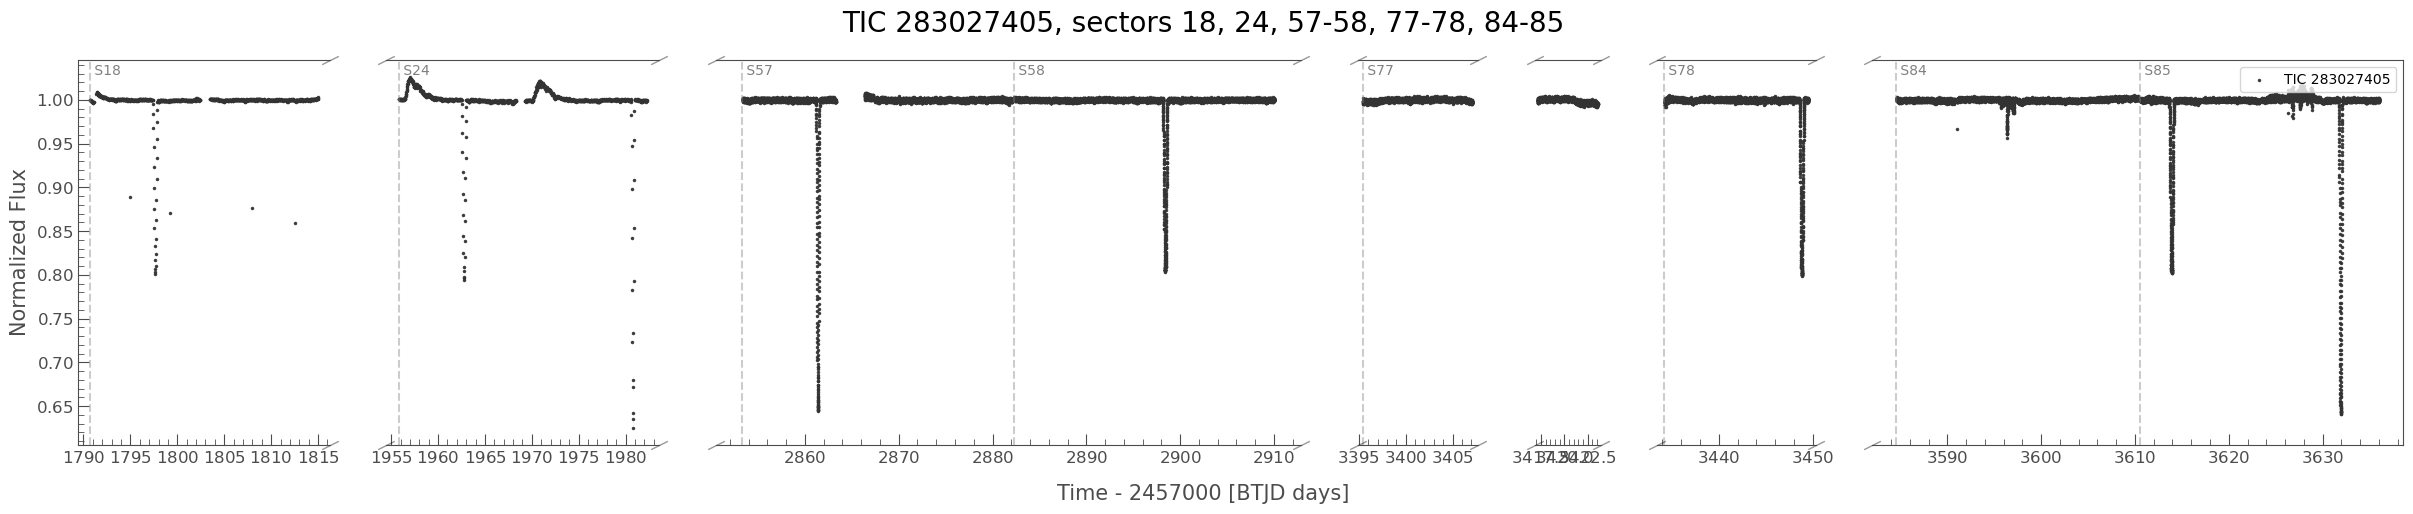

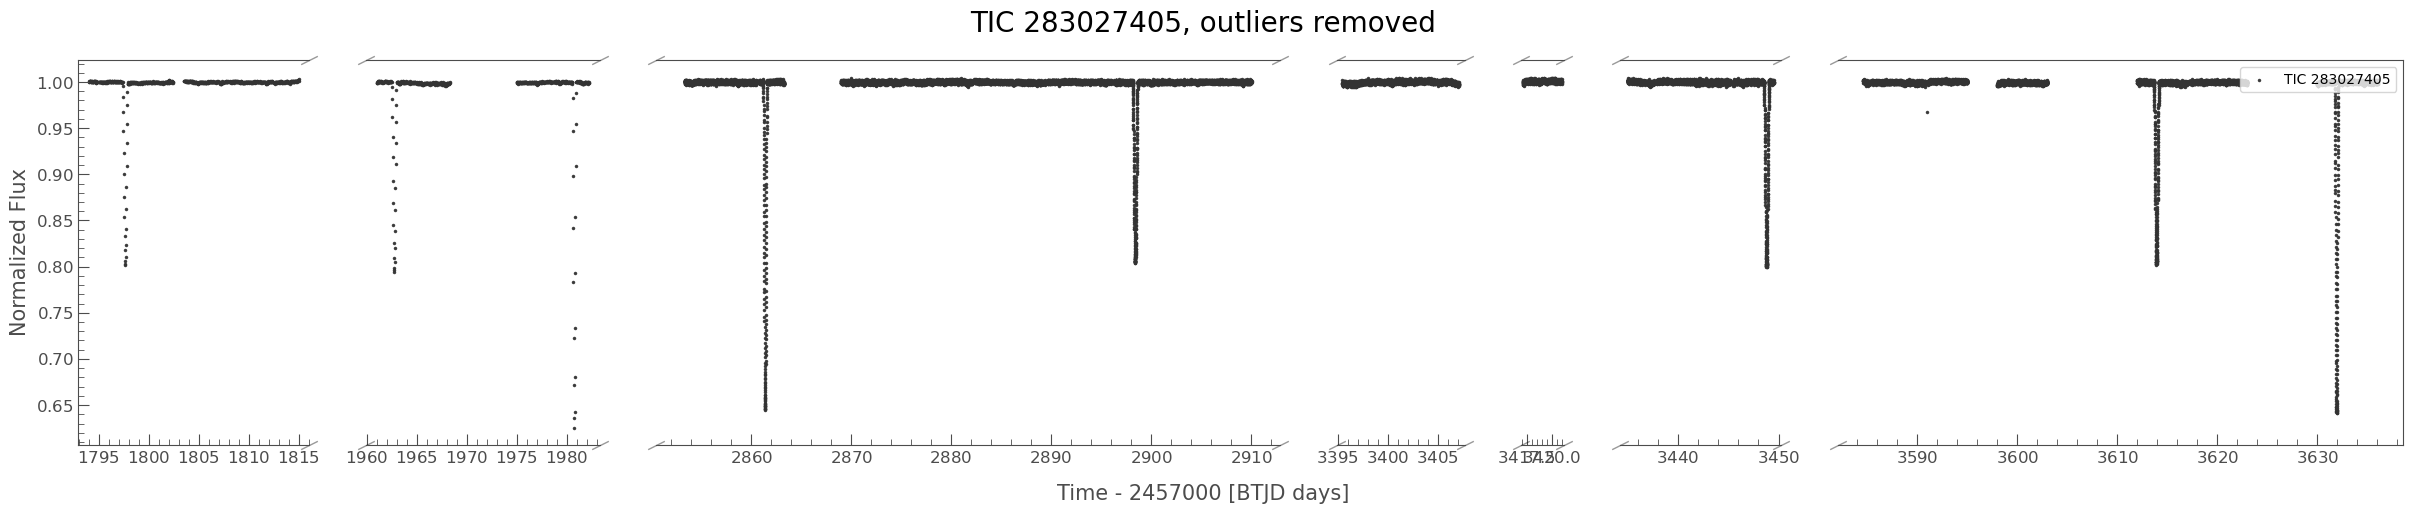

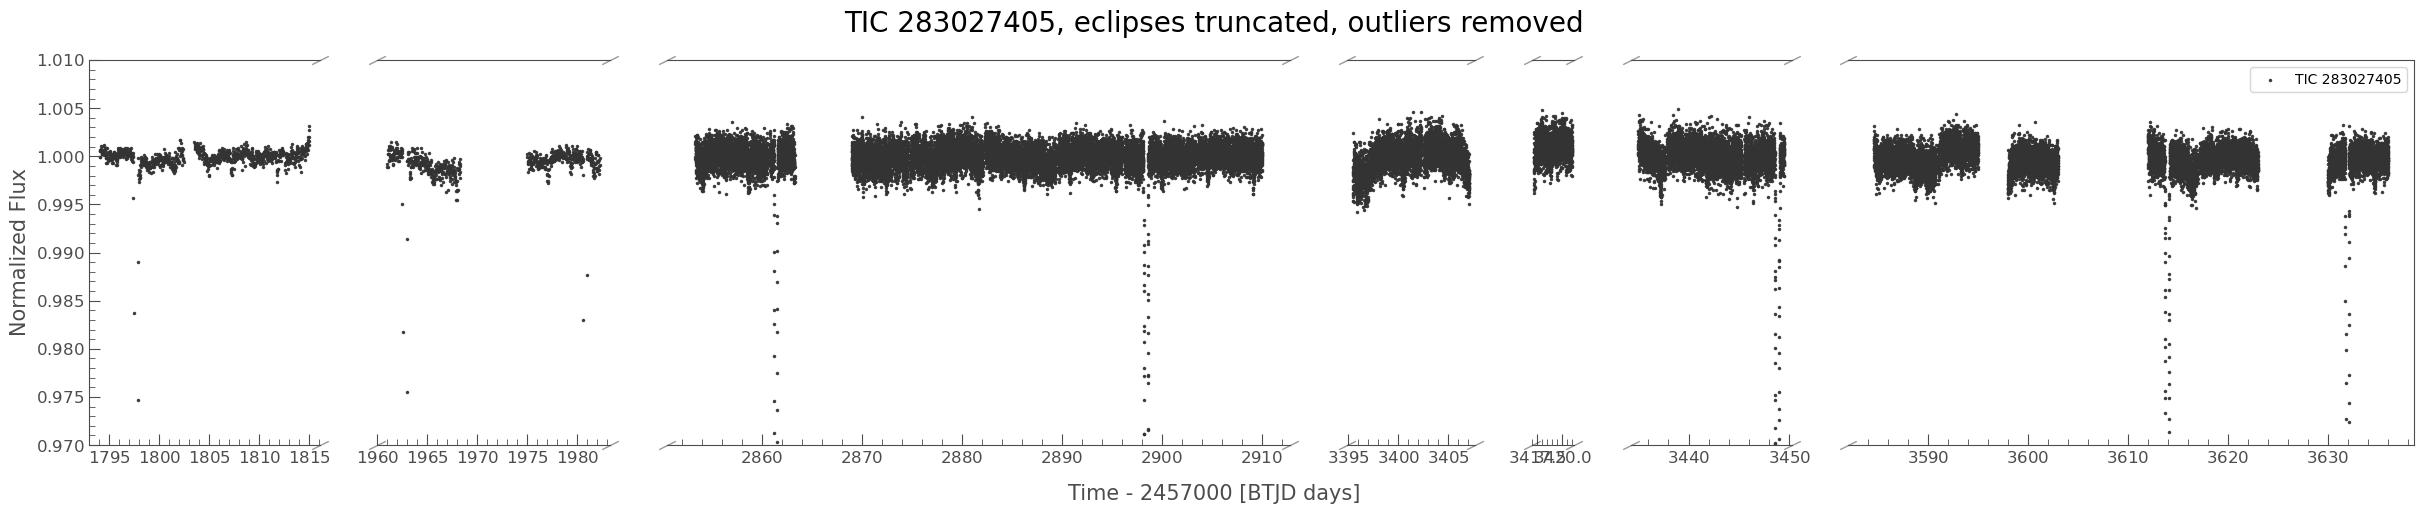

In [64]:
_lc = lke.stitch(lcc_tess, ignore_incompatible_column_warning=True,)  # corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()
# _lc_all = _lc  # retain a copy
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}", fontsize=20);

# remove outliers, do it in BTJD as it's more familiar to me

for xstart, xstop in [  # scattered light, and systematics
    (1790, 1794), 
    (1955, 1961),
    (1969, 1975),
    (2866, 2869),
    (3421, 3424),
    (3434, 3435),
    (3595, 3598),
    (3603, 3612), 
    (3623, 3630),
]:
    _lc = lke.exclude_range(_lc, xstart, xstop)

# QKP sector 18 data has lone outliers associated with momentum dumps, exclude the time around them
for t in np.unique(np.round(lket.MomentumDumpsAccessor.get_in_range(start=1790, end=1816), 2)):
    _lc = lke.exclude_range(_lc, t - 0.05, t + 0.05)
    
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, outliers removed", fontsize=20);

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, eclipses truncated, outliers removed", fontsize=20);
[ax.set_ylim(0.97, 1.01) for ax in axs];

# convert to mag and HJD
lc_tess = _lc
lc_tess = lke.to_flux_in_mag_by_normalization(lc_tess)
lc_tess = lke.convert_lc_time_to_hjd_utc(lc_tess, target_coord=target_coord, cache_dir=lk_download_dir)



### SuperWASP

Cameras: camera
------
   145
   148


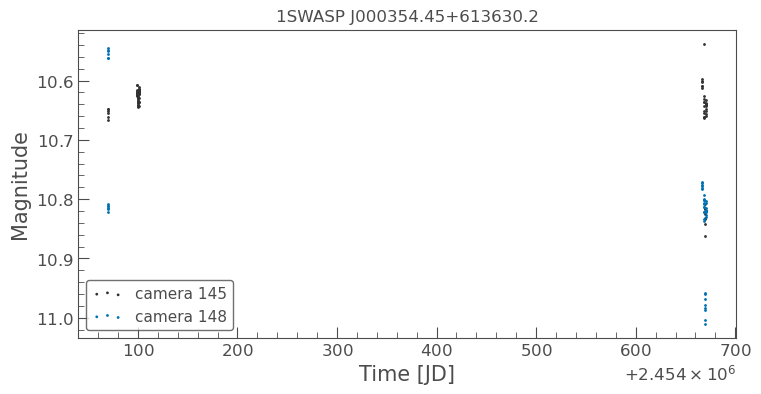

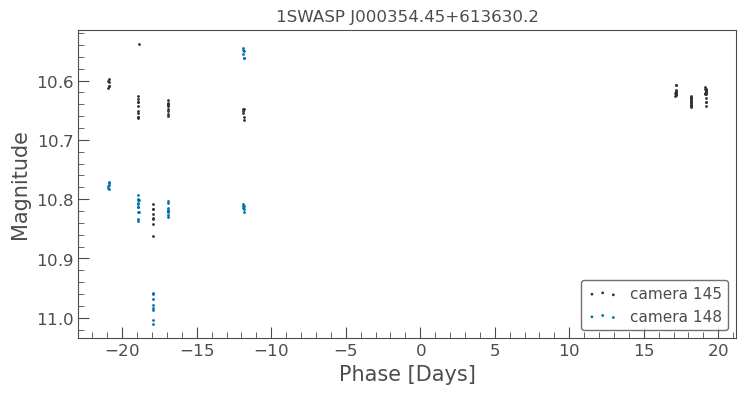

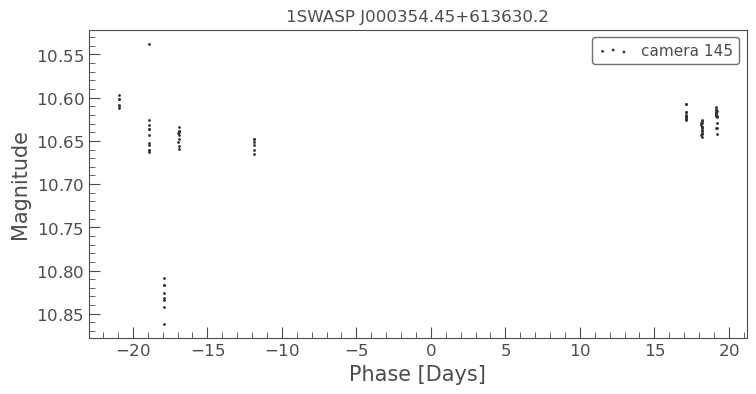

In [59]:
import lightkurve_ext_readers as lker

_lc = lker.read_superwasp_dr1_data("1SWASP J000354.45+613630.2")
_lc = lke.to_flux_in_mag_by_normalization(_lc, base_mag=10.64428)  # from SuperWASP
print("Cameras:", np.unique(_lc.camera));
tplt.scatter_partition_by(_lc, "camera");

# SuperWASP data has zero point issue. Use only camera 145 as it's the one that has eclipse data
_lc_f = _lc.fold(period=55.04, epoch_time=Time(2861.39, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter_partition_by(_lc_f, "camera");
_lc = _lc[_lc.camera == 145]

_lc_f = _lc.fold(period=55.04, epoch_time=Time(2861.39, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter_partition_by(_lc_f, "camera");

lc_swasp = _lc

### ASAS-SN SkyPatrol (skipped)

- skipped. The data likely to have scatter that is too large, based on the esimate from SkyPatrol v2 data
  - http://asas-sn.ifa.hawaii.edu/skypatrol/objects/120259868158

### Do Actual combining

TESS # data points: 49634
1SWASP # data points: 84


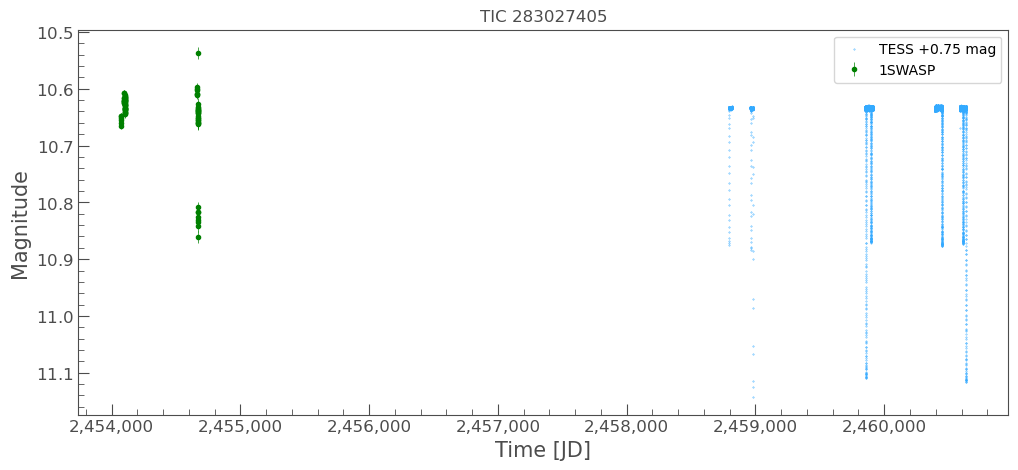

In [66]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)

lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess, 
     "1SWASP": lc_swasp,
    }, 
    shift_to="1SWASP",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
# plot_options[0][1]["zorder"] = 3  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(15.2, 14.0);

## Initial epoch / period / duration


Adopted period / epoch / duration_hr:  55.038 2459861.389 9 11.5


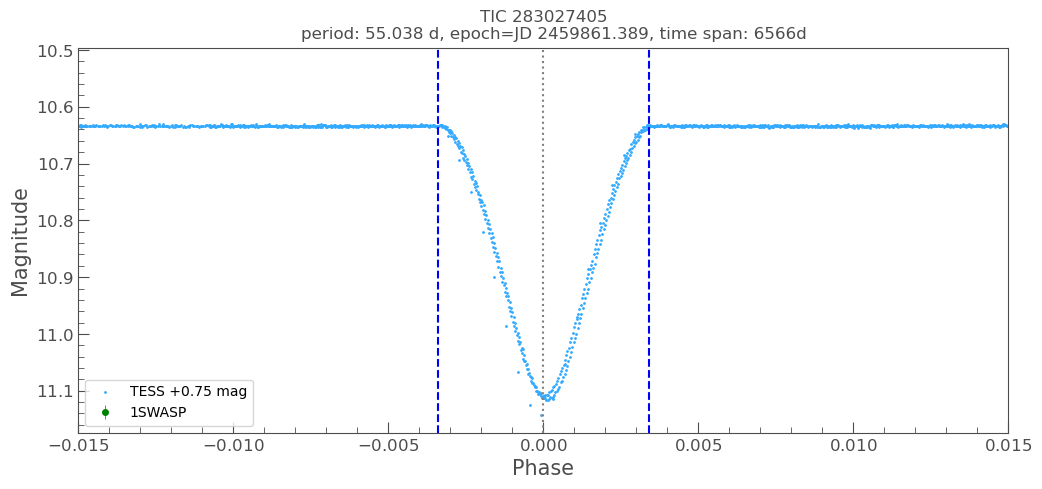

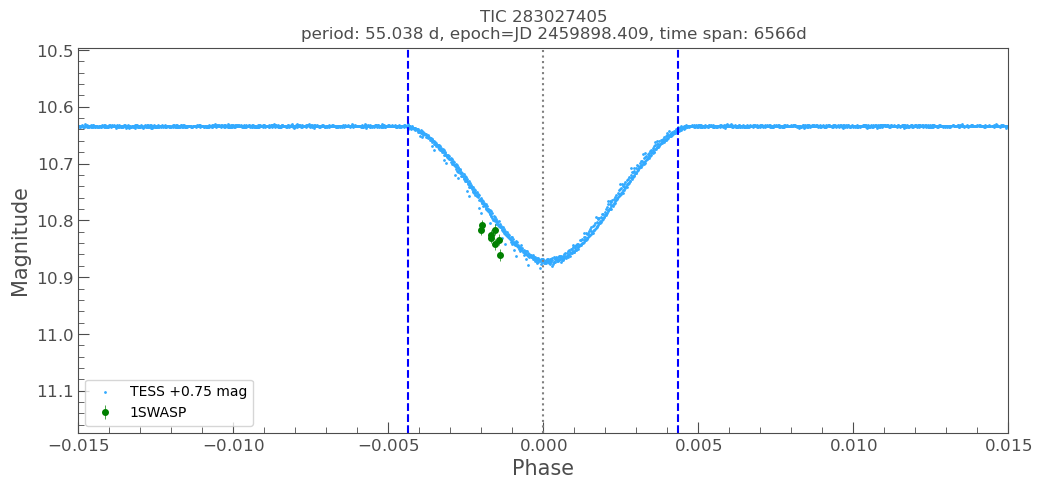

In [75]:
# reload(lkem)

# epoch / period / duration from manual inspection
#     dict(epoch=2861.39, duration_hr=9, period=55.038, label="Min I", transit_depth_percent=35.5,
#         ),
#     dict(epoch=2898.41, duration_hr=11.5, period=55.038, label="Min II", transit_depth_percent=19.5,
#         ),

period_trial = 55.038
epoch_time_btjd_trial = 2861.39
epoch_time_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_btjd_trial, target_coord), 3)  # need 3 digit to ensure it does look off visually

# from visual inspection
epoch_time_min_ii_hjd_trial = epoch_time_hjd_trial + (2898.41 - 2861.39)
duration_hr_min_i_trial = 9
duration_hr_min_ii_trial = 11.5


print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial, duration_hr_min_ii_trial)

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
# plot_options_zoom[0][1]["zorder"] = 3  # move to the front, default 2
plot_options_zoom[1][1].update(dict(marker='o', markersize=4))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.015, 0.015);  # to see primary in details
ax.set_ylim(*ylim);


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_min_ii_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.015, 0.015);  # to see primary in details
ax.set_ylim(*ylim);


## Period refinement with MCMC on secondary eclipses

- use secondary eclipses as 1) it has some more data in TESS, and 2) it has some data in SuperWASP (thus lengthening the baseline)

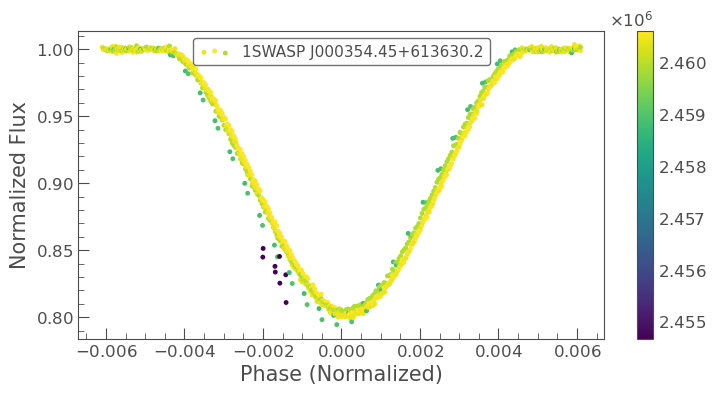

In [76]:
_lc = lke.stitch_lc_dict(lc_combined_dict, normalize=True).remove_nans()

lc_f_min_ii = _lc.fold(epoch_time=epoch_time_min_ii_hjd_trial, period=period_trial, normalize_phase=True)
lc_f_min_ii = lc_f_min_ii.truncate((0 - duration_hr_min_ii_trial / 24 * 0.7) / period_trial, (0 + duration_hr_min_ii_trial /24 * 0.7) / period_trial)
lc_f_min_ii = lc_f_min_ii.truncate(None, 1.2, column="flux")  # crude outlier removal
ax1 = tplt.scatter(lc_f_min_ii, c=lc_f_min_ii.time_original.value, s=25);
# ax1 = tplt.errorbar(lc_f_min_ii);

In [79]:
from types import SimpleNamespace

import sys
if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
    sys.path.append("../eb_with_diff_sb_period/etv/")

import etv_functions_with_period as etvp
import etv_functions
# reload(etv_functions)

lc_f = lc_f_min_ii

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalixed phase
start_vals = [1.0, -0.195, 0, 0.002, 1.1]


# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.0, -0.195, 0, 0.002, 1.1]\n\n', '…

100%|██████████████████████████████████████████████████████████| 4000/4000 [02:09<00:00, 30.83it/s]


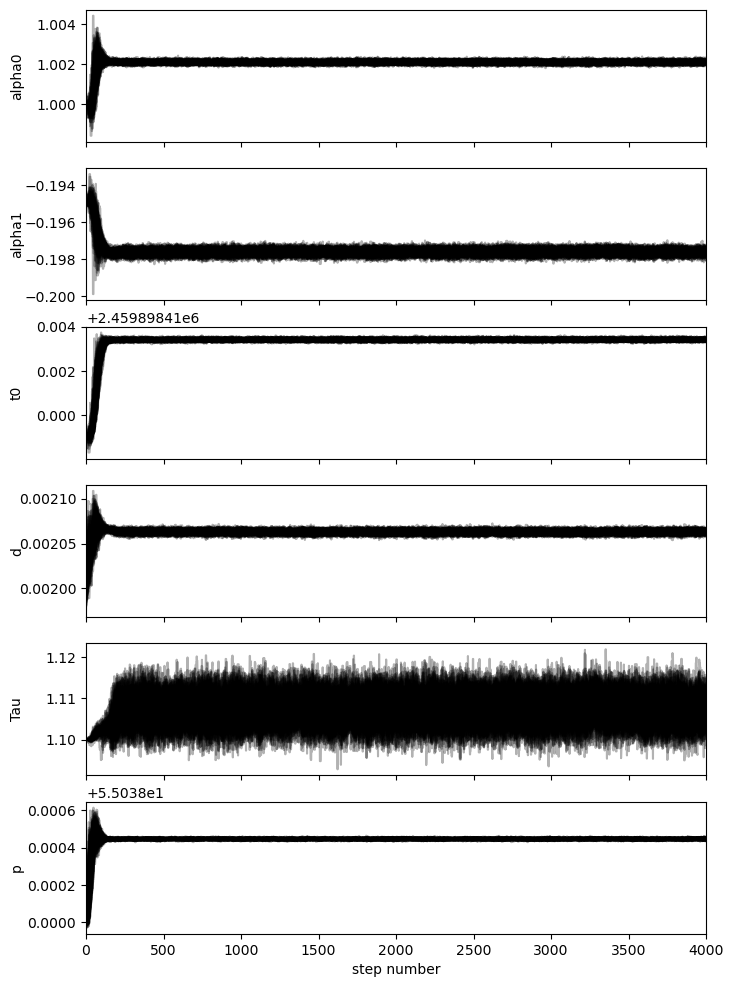

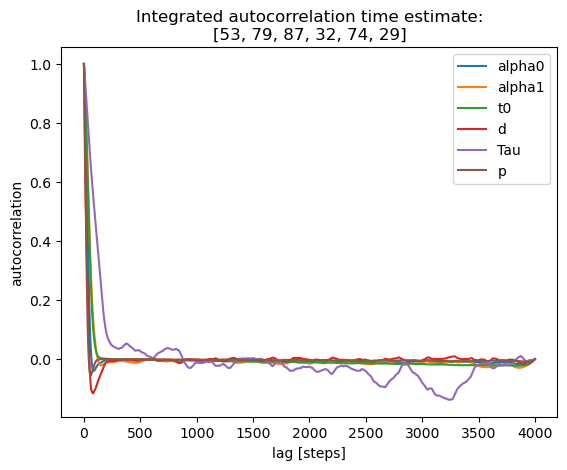

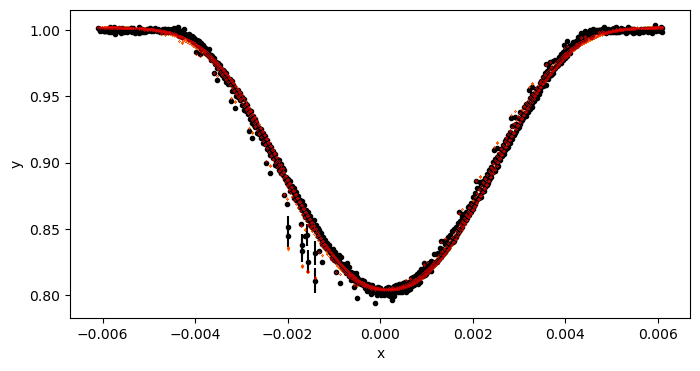

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 1.002091044069671, -0.1976118611837729, 2459898.4134110333, 0.0020628372308292035, 1.10758401266881, 55.03844636723019
std_t0: 4.816126048113944e-05
std_p: 3.843492191764869e-06


In [82]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.0, -0.195, epoch_time_min_ii_hjd_trial, 0.002, 1.1, period_trial],
    # nruns=20, discard=1,
    nruns=4000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2, 
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


#### Refinement of Min I epoch with MCMC

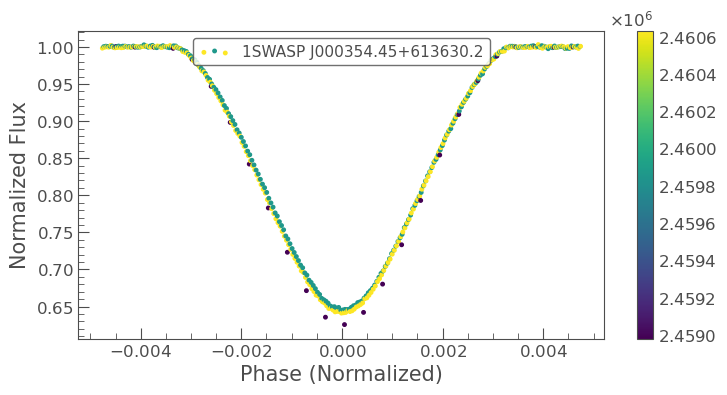

In [107]:

_lc = lke.stitch_lc_dict(lc_combined_dict, normalize=True).remove_nans()

_p = 55.0384  # from MCMC on Min II above
lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=_p, normalize_phase=True)
lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 0.7) / _p, (0 + duration_hr_min_i_trial /24 * 0.7) / _p)
lc_f_min_i = lc_f_min_i.truncate(None, 1.2, column="flux")  # crude outlier removal
ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
# ax1 = tplt.errorbar(lc_f_min_i);


In [108]:
lc_f = lc_f_min_i

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalixed phase
start_vals = [1.0, -0.36, 0, 0.0014, 1.1]


# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.0, -0.4, 0, 0.0015, 1.1]\n\n', 'o…

100%|██████████████████████████████████████████████████████████| 4000/4000 [00:47<00:00, 84.64it/s]
The chain is shorter than 20 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/20 = 200;
tau: [189.78551558 154.5042696   28.9957947  225.20652611 247.44835054]


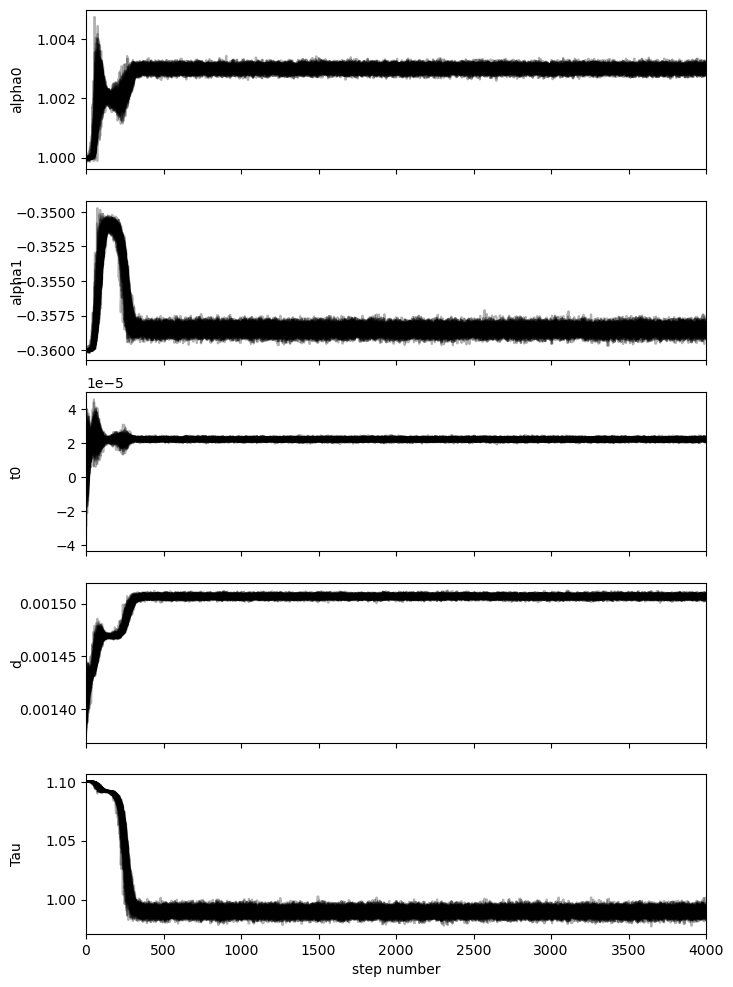

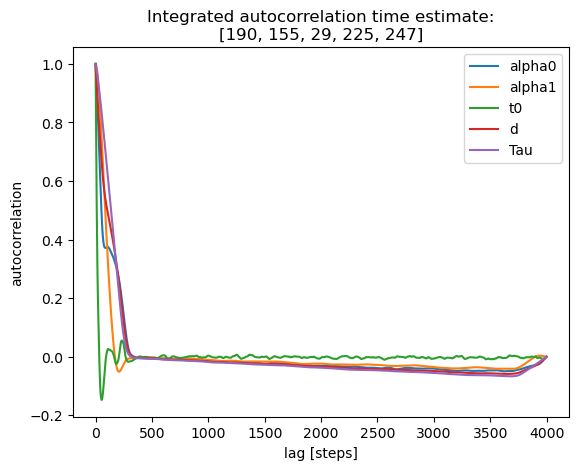

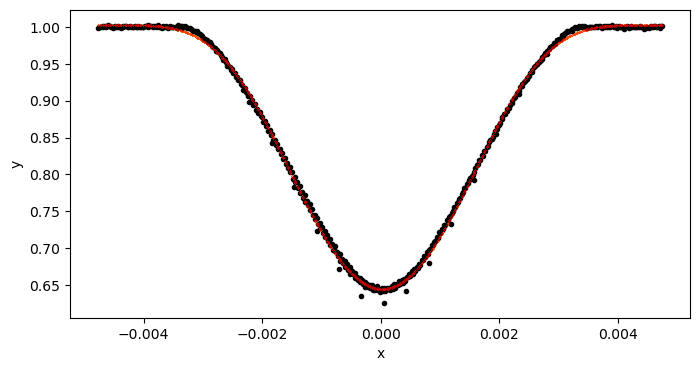

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, = 1.0030018150920212, -0.358523190000427, 2.2047917381450713e-05, 0.0015068826990631374, 0.9894948880983805
t0 in jd: 2459861.3897077125
std_t0 in d: 3.3472643279100466e-05


In [113]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, fit_params_stats  = etv_functions.run_mcmc_initial_fit(
    lc_f_data, 
    [1.0, -0.36, 0, 0.0014, 1.1],
    # nruns=20, discard=1,
    nruns=4000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2, 
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau]]))
# convert the modeled t0 from phase to time
print("t0 in jd:", epoch_time_hjd_final + _p * 1.2858520204097378e-05);
print("std_t0 in d:", fit_params_stats["std_t0"] * _p)


In [114]:
epoch_time_hjd_trial

2459861.389

## Final period / epoch / duration

Adopted period / epoch / duration_hr:  55.0384 2459861.390 0.6727 9 11.5


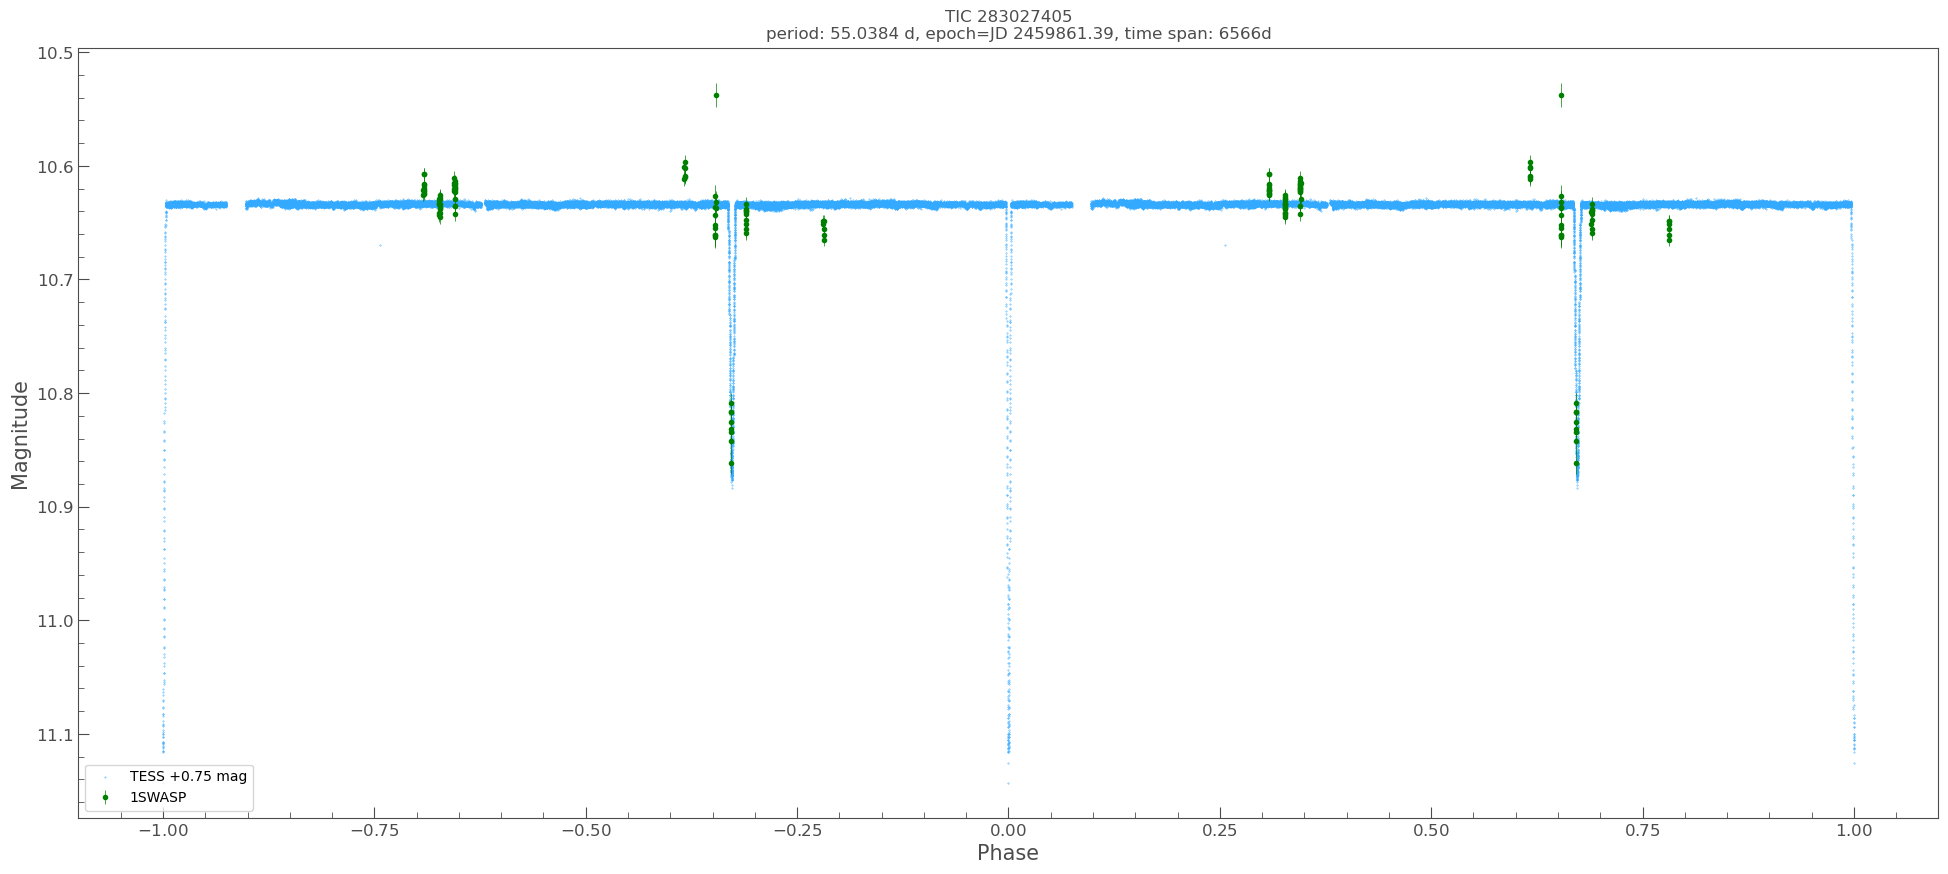

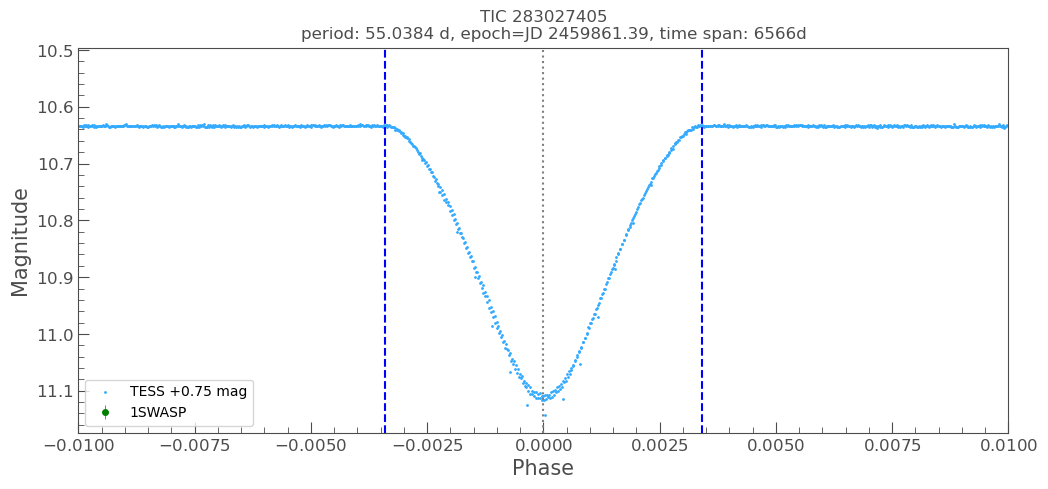

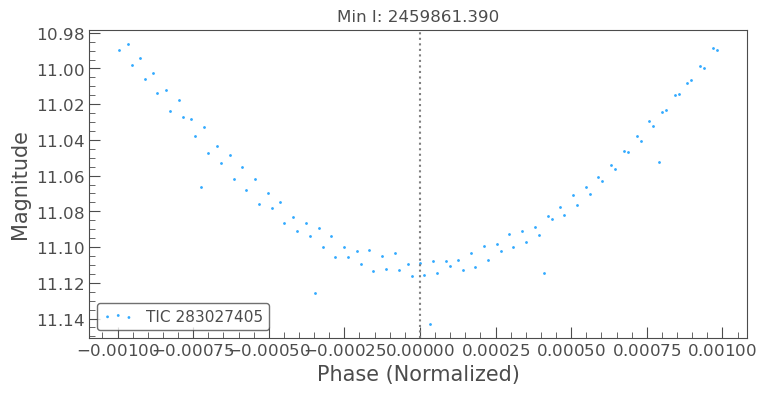

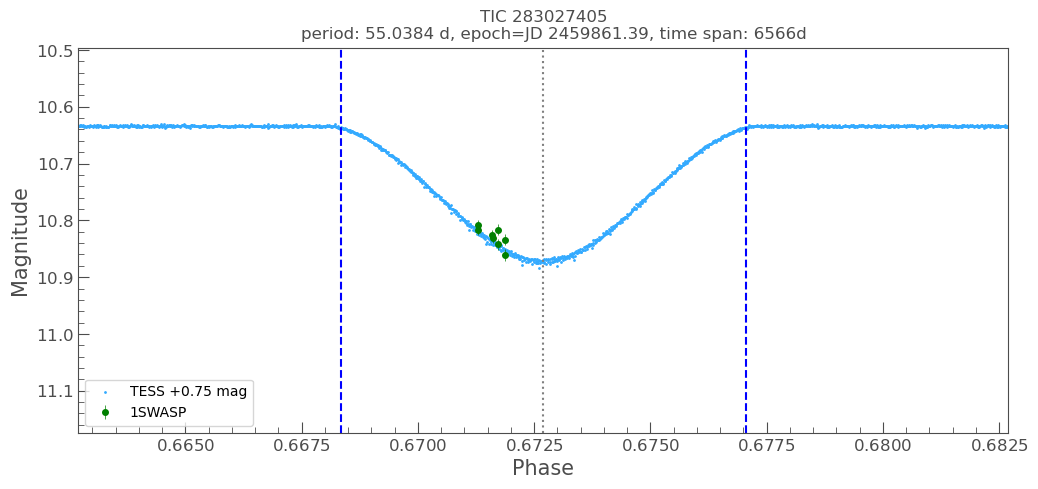

In [125]:
# reload(lkem)
from decimal import Decimal

period_final = 55.0384   # from MCMC value 55.03844636723019, precision adjusted from inspecting folded LC below
epoch_time_hjd_final = Decimal("2459861.390")  # from MCMC value 2459861.3897077125, , precision adjusted from inspecting folded LC below
duration_hr_min_i_final = duration_hr_min_i_trial 

epoch_time_min_ii_hjd_final = 2459898.413  # from MCMC
epoch_phase_min_ii_final   = abs(epoch_time_min_ii_hjd_final   - float(epoch_time_hjd_final)  ) / period_final   % 1
# if epoch_phase_min_ii_final   > 0.5:
#     epoch_phase_min_ii_final   = epoch_phase_min_ii_final   - 1
epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 4)  # precsion from eyeballing zoomed plot
duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final, epoch_phase_min_ii_final, duration_hr_min_i_final, duration_hr_min_ii_final)

# --- plot to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
# plot_options_zoom[0][1]["zorder"] = 3  # move to the front, default 2
plot_options_zoom[1][1].update(dict(marker='o', markersize=4))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.01, 0.01);  # to see primary in details
ax.set_ylim(*ylim);

ax = tplt.scatter(lc_f_res["TESS"].truncate(-0.001, 0.001), c="#3AF");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_title(f"Min I: {epoch_time_hjd_final}");

# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_final  ,  # for plotting only
    duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final -0.01, epoch_phase_min_ii_final + 0.01);  # to see primary in details
ax.set_ylim(*ylim);


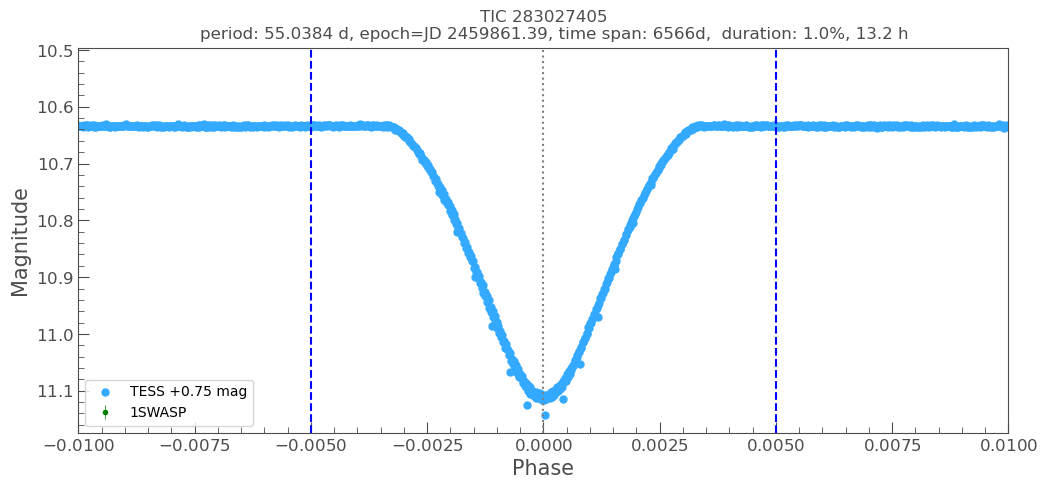

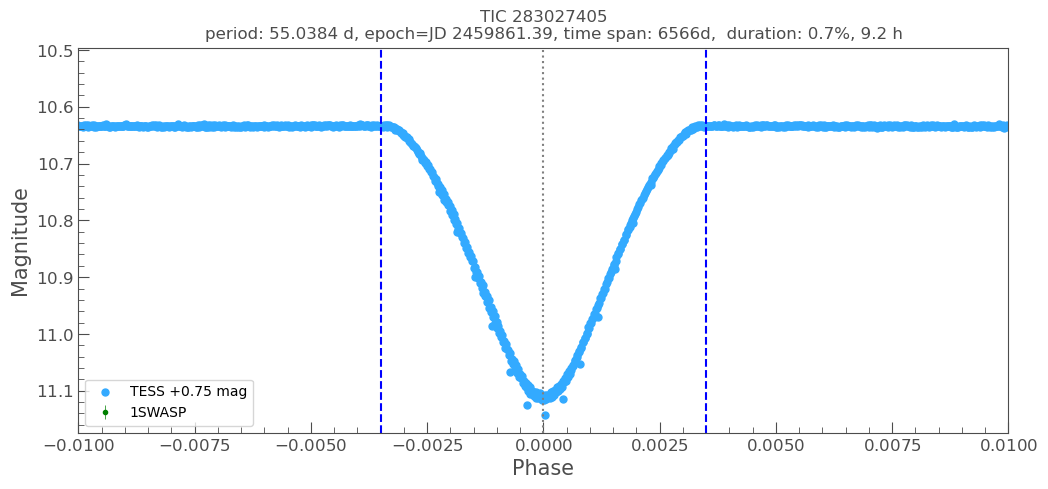

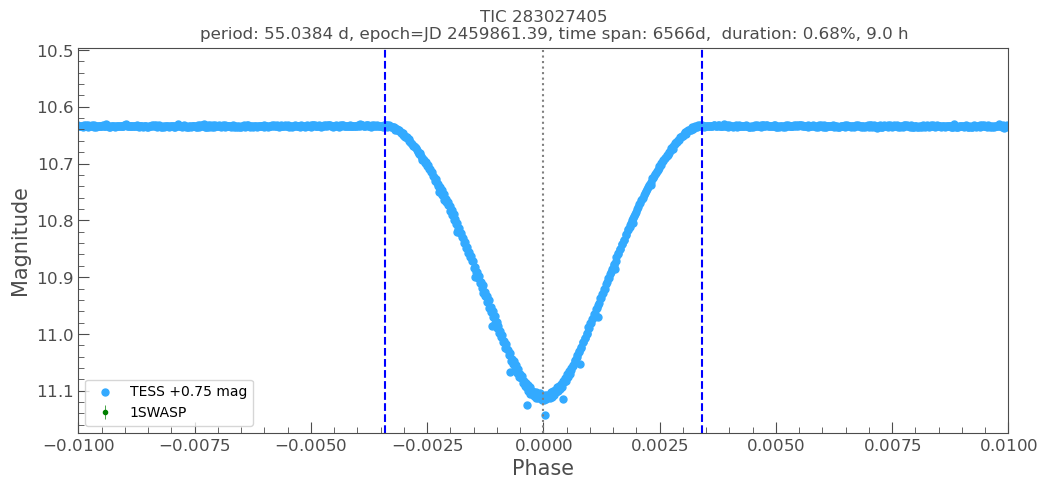

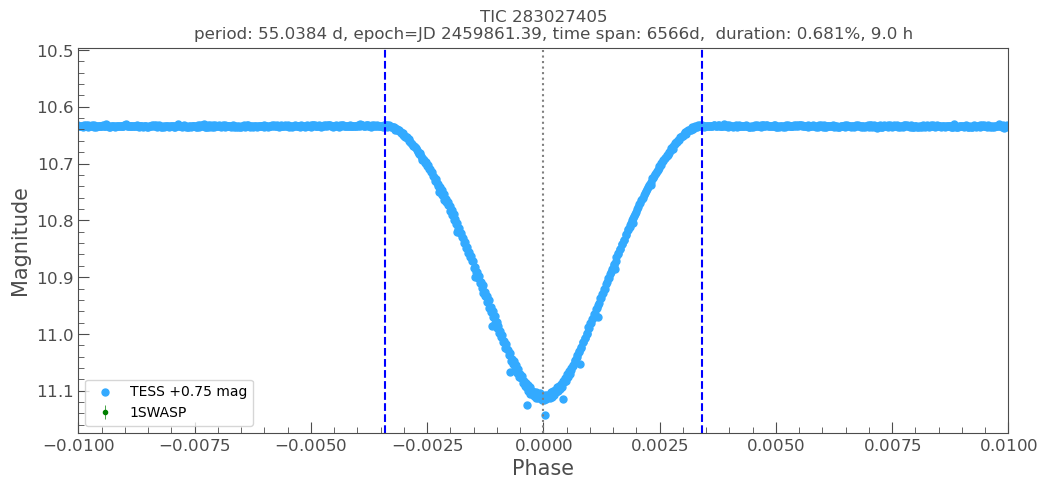

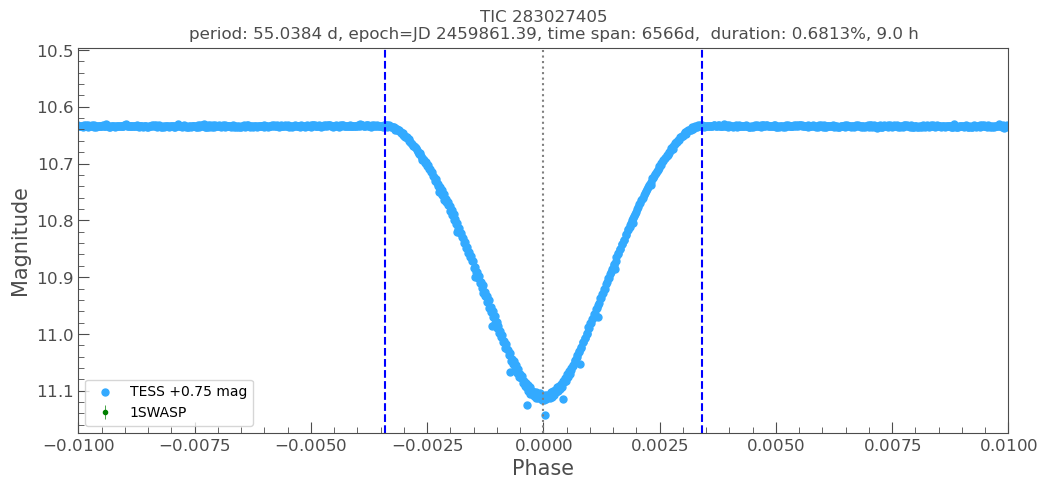

In [126]:
# demonstrate the precision difference in duration percentage 
# - 2 digits for percetnarge would be appropriate
for _precision in [0, 1, 2, 3, 4]: 
    _dur_pct = round(100 * duration_hr_min_i_final / 24 / period_final, _precision)
    _dur_hr = _dur_pct /100 * 24 * period_final
    # zoom plot Min I
    # - make TESS more visible:  larger dots
    plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
    plot_options_zoom[0][1]["s"] = 25
    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict,
        period=period_final,
        epoch=Time(epoch_time_hjd_final  , format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
        target_name=primary_name,
        duration_hr=_dur_hr,  # for plotting only
        figsize=(12, 5),
        plot_options=plot_options_zoom,
        # mag_shift_precision=2,  #
    );
    ax.set_ylim(*ylim);
    ax.legend(loc="lower left");
    ax.axvline(0, c="gray", linestyle="dotted");
    ax.set_xlim(-0.01, 0.01);  # to see primary in details
    ax.set_title(ax.get_title() + f",  duration: {_dur_pct}%, {_dur_hr:.1f} h");
    # print(_dur_pct, _dur_hr, duration_hr_min_i_final) 

## Determine Amplitude (TESS)


Min I mag # num data points: 6
Min II mag # num data points: 7
['10.6338', '11.1126']


(0.48, 0.24)

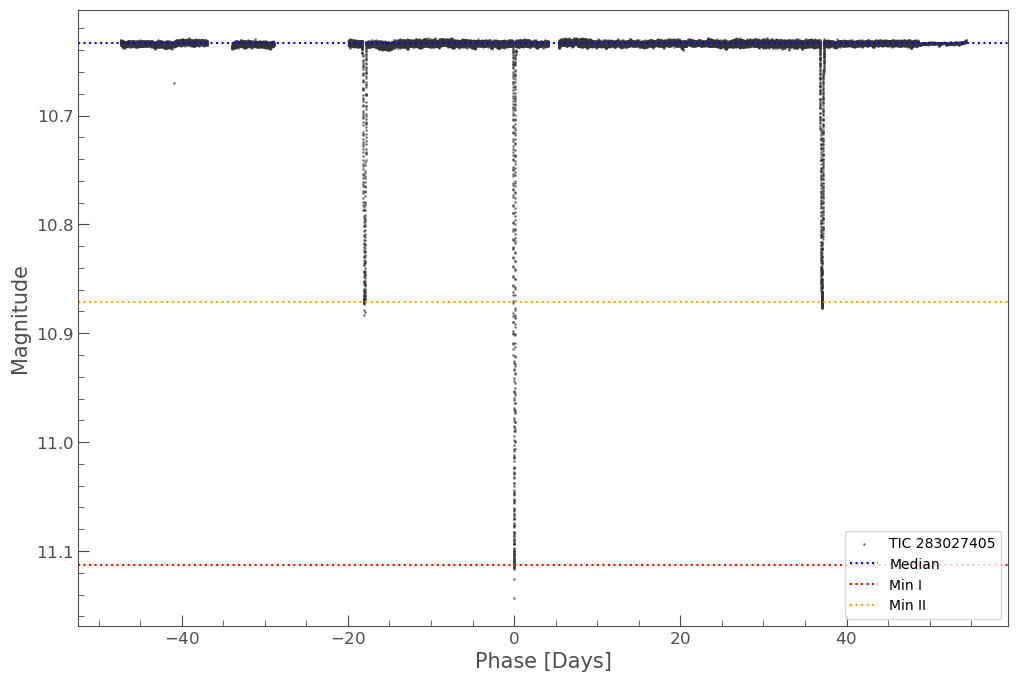

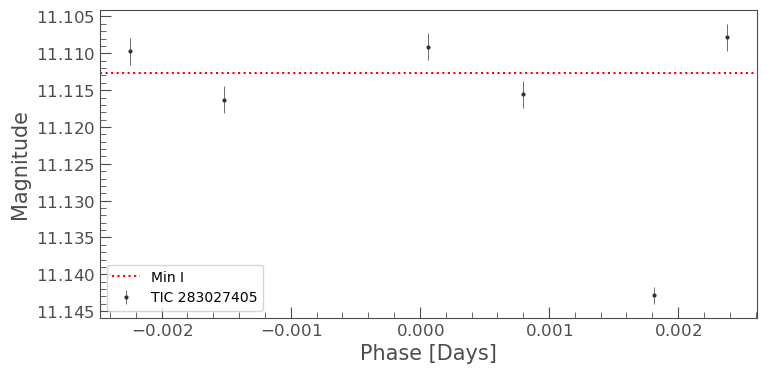

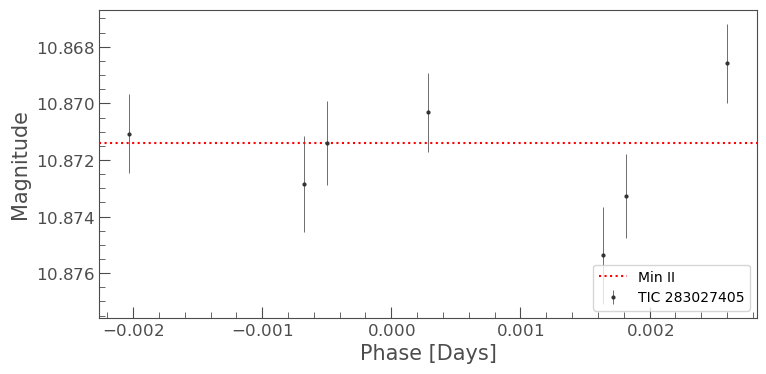

In [158]:
# %matplotlib widget
%matplotlib inline

# From TESS data
lc = lc_combined_dict["TESS"]

# max_flux_mag = lc.flux.min().value  #
# min_flux_mag = lc.flux.max().value
median_flux_mag = np.nanmedian(lc.flux.value)

# no max neded, medain is basically max
# lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + 0.75, period=period_final).truncate(0 - 1 /24/60, 0 + 1 /24/ 60)  
# print("Max mag # num data points:", len(lc_zoom_max))
# max_flux_mag = np.nanmedian(lc_zoom_max.flux.value)

lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final).truncate(0 - 4 /24/60, 0 + 4 /24/ 60)
print("Min I mag # num data points:", len(lc_zoom_min))
min_flux_mag = np.nanmedian(lc_zoom_min.flux.value)

lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 4 /24/60, 0 + 4 /24/ 60)
print("Min II mag # num data points:", len(lc_zoom_min_ii))
min_ii_flux_mag = np.nanmedian(lc_zoom_min_ii.flux.value)


lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final * 2)  # 2x period plot
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median")
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
ax.axhline(min_ii_flux_mag, c="orange", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ax.set_ylim(*ylim);


ax = tplt.errorbar(lc_zoom_min, marker="o");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.set_ylim(*ylim);
ax.legend();

ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");

print([f"{v:.4f}" for v in [median_flux_mag, min_flux_mag]])  # , min_ii_flux_mag


# # TESS only data, to report mean V mag and ampitude in TESS
# mean_flux_v_mag = np.round(rs_all_cols["Vmag"][0], 2)  # V converted from Gaia DR3 - here I use other sources

# amp_flux_mag = np.round(np.abs(float(min_flux_mag - max_flux_mag)) , 3)  # in TESS band, probably don't have 4 digit precison

amp_min_i_flux_mag = np.round(np.abs(float(min_flux_mag - median_flux_mag)) , 2)  

amp_min_ii_flux_mag = np.round(np.abs(float(min_ii_flux_mag - median_flux_mag)) , 2)  

(amp_min_i_flux_mag, amp_min_ii_flux_mag)  # amp_flux_mag,

## Plots for VSX

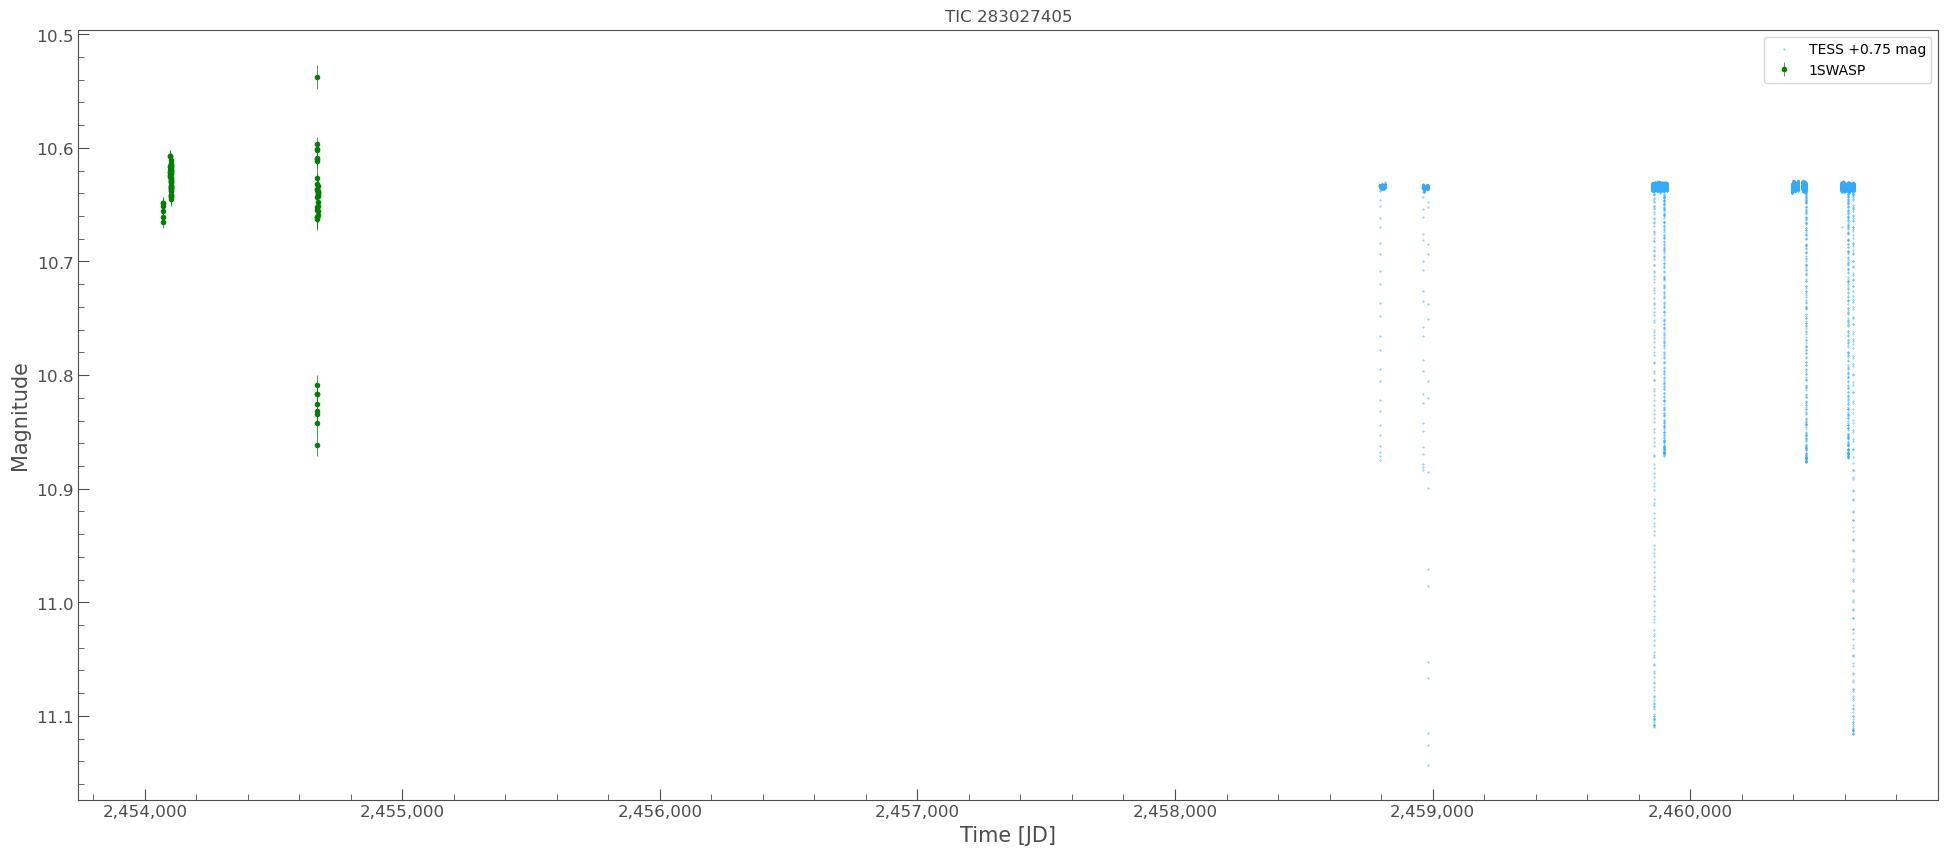

In [133]:
# reload(lkem)
# Not needed
plot_options = lkem.get_default_plot_multi_bands_options_copy()
# plot_options[0][1]["zorder"] = 4

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
# ax.set_title(ax.get_title() + "");

#### Phase Plot



In [146]:
lkem.get_default_plot_multi_bands_options_copy()

[('scatter', {'c': '#3AF', 's': 0.1, 'alpha': 1.0}),
 ('errorbar',
  {'marker': '.',
   'markersize': None,
   'c': 'green',
   'linewidth': 0.5,
   'ls': 'none'}),
 ('errorbar',
  {'marker': '.',
   'markersize': None,
   'c': 'pink',
   'linewidth': 0.5,
   'ls': 'none'}),
 ('errorbar',
  {'marker': '.',
   'markersize': None,
   'c': 'violet',
   'linewidth': 0.5,
   'ls': 'none'}),
 ('errorbar',
  {'marker': '.',
   'markersize': None,
   'c': 'orange',
   'linewidth': 0.5,
   'ls': 'none'})]

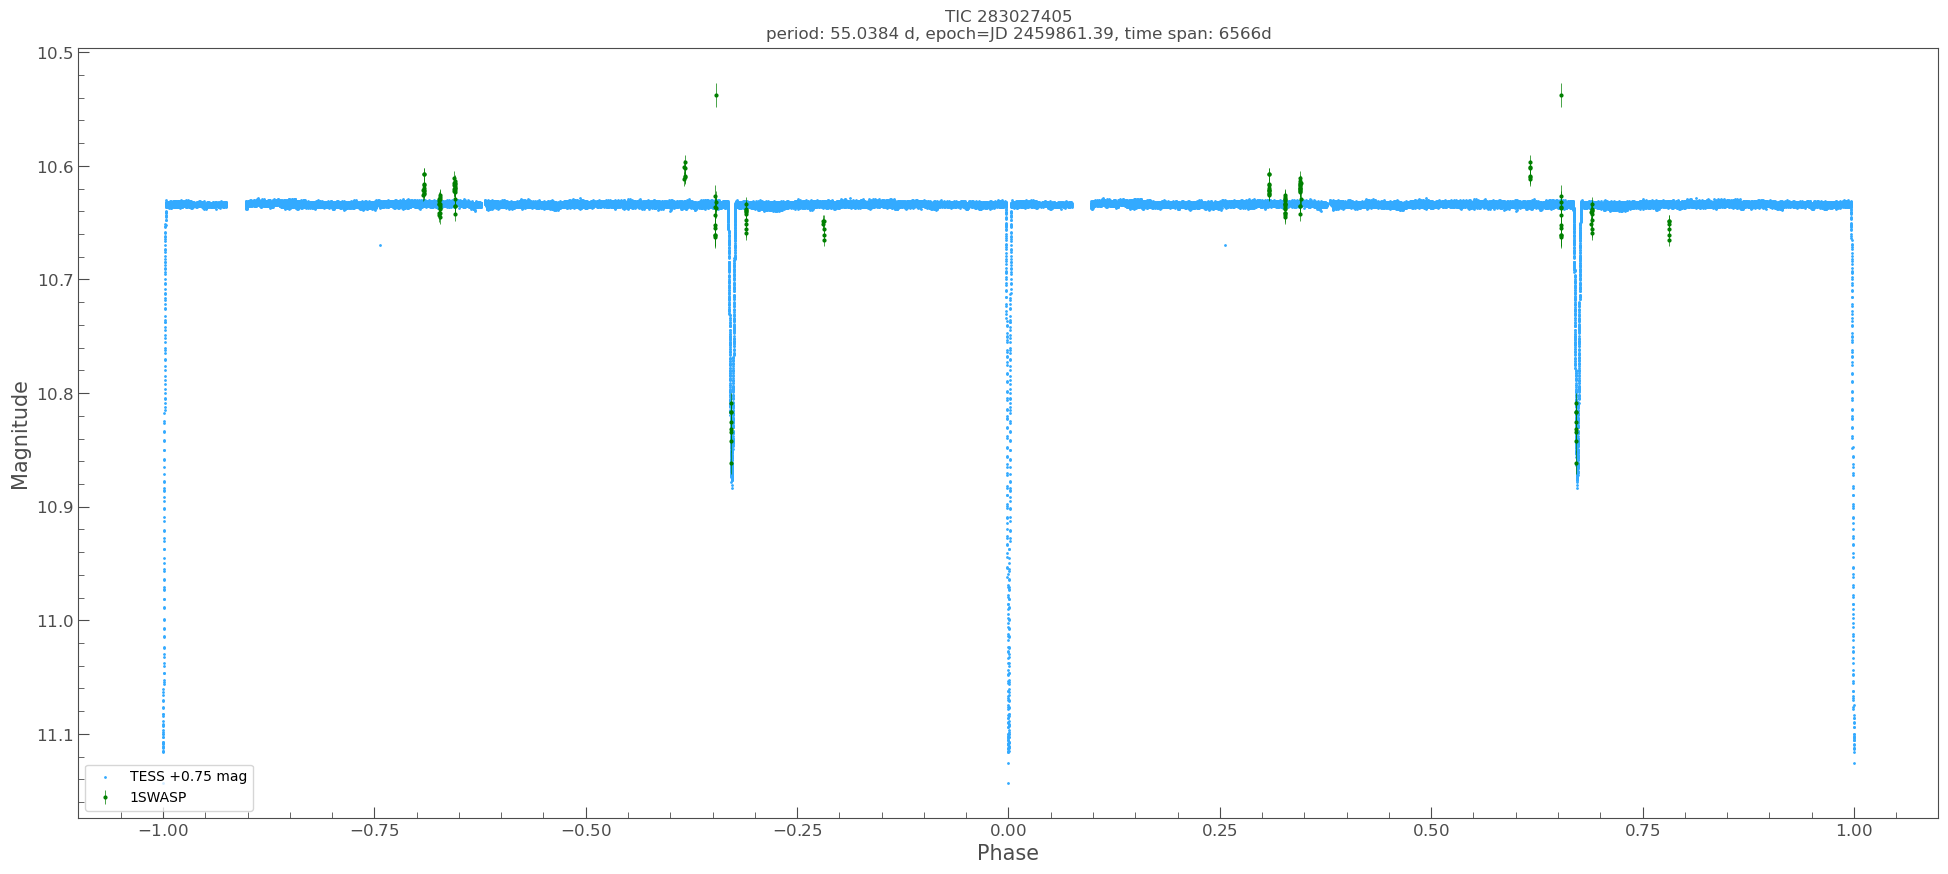

In [152]:
plot_options = lkem.get_default_plot_multi_bands_options_copy()  # use scatter plot , as errrobar is too busy
plot_options[0][1].update(dict(s=1, ))  # make dots larger
plot_options[1][1].update(dict(markersize=4))  # make dots larger

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)  # hide the outliers that are too bright, mostly in ASAS-SN g
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


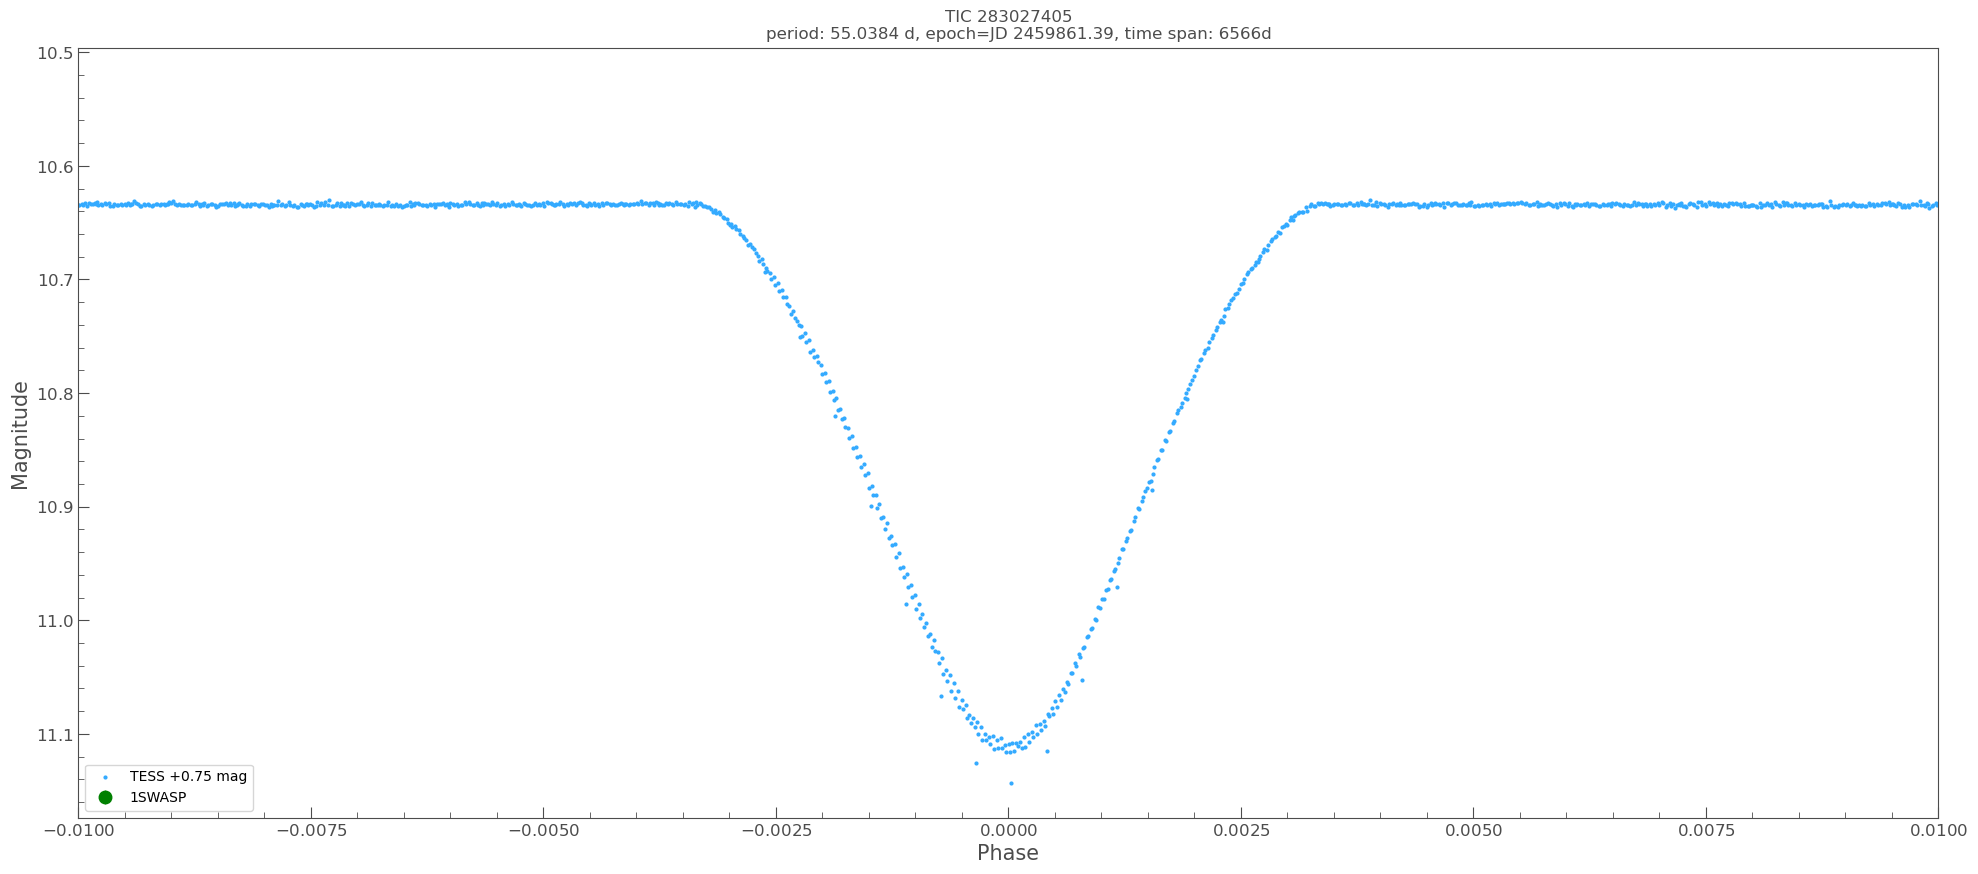

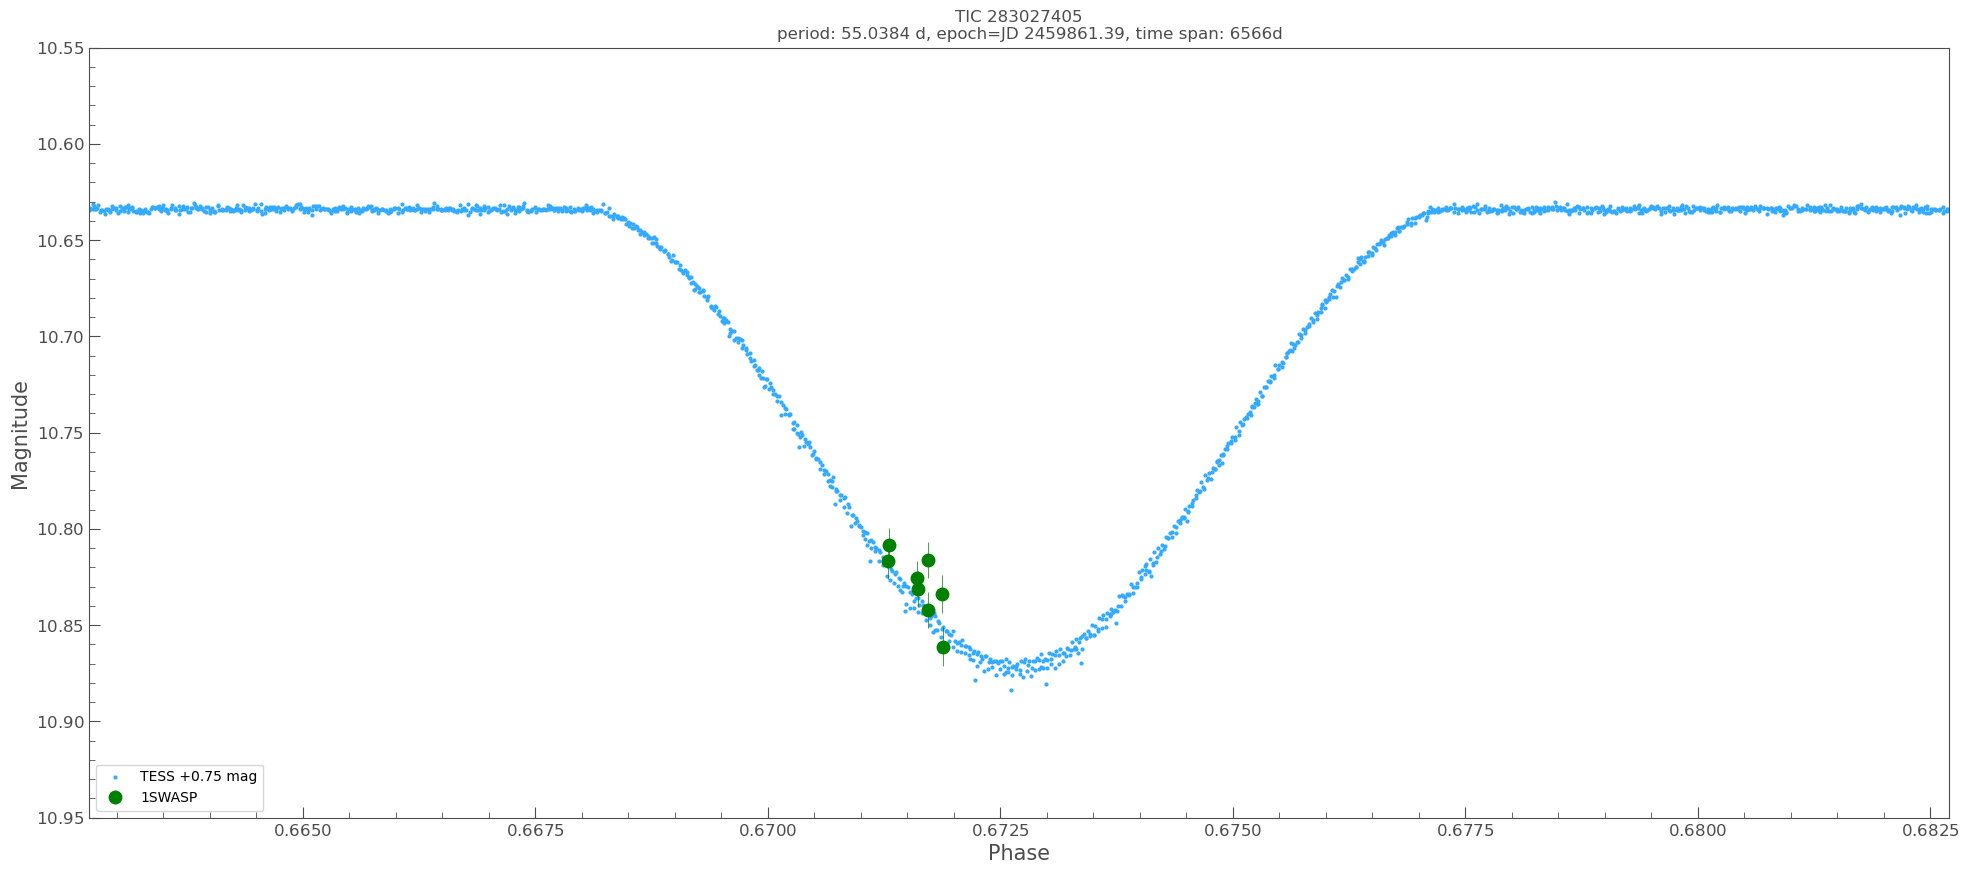

In [153]:
# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1].update(dict(s=4))
plot_options_zoom[1][1].update(dict(marker='o', markersize=9))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.01, 0.01);  # to see primary in details
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_ii_final ,  # for plotting only
    # duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
ax.set_ylim(10.95, 10.55);
# ax.set_title(ax.get_title() + ", outliers truncated");


## VSX Report Table

In [140]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


In [173]:
import bibs_utils
# reload(bibs_utils)


other_names = "TYC 4014-1886-1,2MASS J00035445+6136302"  # in ExoFOP and SIMBAD
other_names +=",GSC 04014-01886"  # in SIMBAD
other_names += ",1SWASP J000354.45+613630.2"  # -- use SuperWASP data


remarks = (
    f"""Eccentric system. Min II at phase {epoch_phase_min_ii_final}, amplitude {amp_min_ii_flux_mag} TESS, duration {100 * duration_hr_min_ii_final / 24 / period_final:.2f}%."""
    f""" TESS data contaminated by additional eclipse signals with 4.59 d period and amplitude ~0.001 TESS: the source is TIC 283027447 / Gaia DR3 429508381862135936, 13.6 V, 36" to the S."""
    f""" See the TCE in the reference."""
)

# Not neeed for initial submission:
# - Type, period, epoch, eclipse duration from TESS and SuperWASP data. Amplitude from TESS data.
revision_comment = "Maximum magnitude derived from Gaia DR3. Gaia DR3 position, spectral type."

BIBS = bibs_utils.BIBS
vsx_report = dict(
    Position=f"{target_coord.ra.value:.5f}, {target_coord.dec.value:.5f}",  # VSX coordinate precision
    Primary_Name=primary_name,
    Other_Names=other_names,
    Variable_Type="EA",
    Spectral_Type="G",  # From Gaia DR3
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"10.48",  # From  Gaia DR3 (fainter than 10.39 V from Tycho-2 on SIMBAD). No GCPD
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{amp_min_i_flux_mag}",
    Minimum_Magnitude_band="TESS",  
    Minimum_Is_Amplitude=True,
    Period=f"{period_final}",  
    Epoch=f"{epoch_time_hjd_final}",  
    Rise_Duration_Pct=f"{100 * duration_hr_min_i_final / 24 / period_final:.2f}",  # 2 decimal point is enough visually
    Discoverer="Sam Lee, Planet Hunters TESS Collaboration",  # PHT Talk:  https://www.zooniverse.org/projects/nora-dot-eisner/planet-hunters-tess/talk/subjects/83935278 , https://www.zooniverse.org/projects/nora-dot-eisner/planet-hunters-tess/talk/search?query=TIC%20283027405
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.QLP_N,
    Reference0_Bib=BIBS.QLP_B,
    Reference1_Name=BIBS.SWASP_N,
    Reference1_Bib=BIBS.SWASP_B,
    Reference2_Name=BIBS.TCE_N(2025),
    Reference2_Link="https://exo.mast.stsci.edu/exomast_planet.html?planet=TIC283027405S0014S0086TCE3",
    # Reference6_Name=BIBS.GAIA_DR3_ASTROPHY_N,
    # Reference6_Bib=BIBS.GAIA_DR3_ASTROPHY_B,
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


print("""
tic283027405_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS and SuperWASP data, shifted to SuperWASP. TESS systematics masked.
tic283027405_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS and SuperWASP data, shifted to SuperWASP. Zoomed around Min I.
tic283027405_phase_plot_eclipses_zoom_min_ii.png : EA Phase Plot (Min II Zoom) - EA Phase Plot from TESS and SuperWASP data, shifted to SuperWASP. Zoomed around Min II.
""")


Other Names (1 line each):
TYC 4014-1886-1
2MASS J00035445+6136302
GSC 04014-01886
1SWASP J000354.45+613630.2

Eccentric system. Min II at phase 0.6727, amplitude 0.24 TESS, duration 0.87%. TESS data contaminated by additional eclipse signals with 4.59 d period and amplitude ~0.001 TESS: the source is TIC 283027447 / Gaia DR3 429508381862135936, 13.6 V, 36" to the S. See the TCE in the reference.

Maximum magnitude derived from Gaia DR3. Gaia DR3 position, spectral type.


,Field,Value
0,Position,"0.97688, 61.60839"
1,Primary_Name,TIC 283027405
2,Other_Names,"TYC 4014-1886-1,2MASS J00035445+6136302,GSC 04014-01886,1SWASP J000354.45+613630.2"
3,Variable_Type,EA
4,Spectral_Type,G
5,Spectral_Type_Uncertain,False
6,Maximum_Magnitude,10.48
7,Maximum_Magnitude_band,V
8,Minimum_Magnitude,0.48
9,Minimum_Magnitude_band,TESS



tic283027405_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS and SuperWASP data, shifted to SuperWASP. TESS systematics masked.
tic283027405_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS and SuperWASP data, shifted to SuperWASP. Zoomed around Min I.
tic283027405_phase_plot_eclipses_zoom_min_ii.png : EA Phase Plot (Min II Zoom) - EA Phase Plot from TESS and SuperWASP data, shifted to SuperWASP. Zoomed around Min II.

